<a href="https://colab.research.google.com/github/dazzens/dazzens/blob/main/EDA_%D0%BF%D1%80%D0%BE%D0%B5%D0%BA%D1%82.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

------------------
---------
-----

# **Пет проект EDA (исследовательский анализ данных).**




Автор: А.Г.Х.

Начало: 22.06.2026


Окончание: 14.08.2026

----



##**Бизнес-контекст**

Датасет содержит транзакции британского интернет-магазина подарков и товаров для дома за один год. Покупатели представлены в Великобритании и других странах. Исследование направлено на анализ денежных показателей операций, ассортимента, поведения клиентов и географии продаж.



-----

# **Цель исследования**


- Выявить ключевые факторы, влияющие на динамику продаж интернет-магазина, для разработки рекомендаций по увеличению выручки и удержанию клиентов.


##**Вопросы:**



1. Как менялись продажи по месяцам: денежный объём операций, количество заказов и сезонность?
2. Какие товары лидируют по количеству единиц, денежному объёму и частоте заказов?
3. Каковы средний и медианный чек, а также размер корзины?
4. Какие страны формируют наибольший денежный объём, количество заказов и средний чек?
5. Какие клиенты формируют наибольшую сумму покупок и частоту заказов?
6. Как цена связана с количеством продаж?
7. Какие товары, страны и клиентские группы вносят наибольший вклад в денежный объём операций?


## **Содержание проекта**



1.  **Первичный осмотр и подготовка данных**
    *   Импорт библиотек и загрузка данных.
    *   Предварительный анализ структуры данных (типы, объем, пропуски).
    *   Преобразование типов данных (`Date` в `datetime`, `CustomerNo` в `int`).
    *   Проверка и обработка пропусков (`CustomerNo`).
    *   Проверка дубликатов и выбросов (`Price`, `Quantity`).

2.  **Предварительный анализ и создание новых признаков**
    *   Расчет общих метрик (общая выручка, количество заказов, количество клиентов, средний чек).
    *   Создание признаков: месяц, день недели, год из даты.
    *   Создание признака: общая сумма заказа (`Price` x `Quantity`).
    *   Агрегация данных на уровне заказа (`TransactionNo`) для анализа корзины.

3.  **Исследовательский анализ данных (EDA)**
    *   Анализ динамики продаж: выручка и количество заказов по месяцам, сезонность.
    *   Анализ товаров: топ-10 по выручке, топ-10 по количеству продаж, распределение цен.
    *   Анализ корзины: среднее количество товаров в заказе, средний чек, распределение заказов по сумме.
    *   Анализ клиентов: топ-10 по сумме трат, топ-10 по частоте покупок, новые, повторные клиенты.
    *   Географический анализ: выручка и количество заказов по странам, средний чек по странам.
    *   Анализ ценовых сегментов: зависимость количества продаж от цены.

4.  **Ключевые выводы и рекомендации**
    *   Формирование основных инсайтов по каждому блоку анализа.
    *   Разработка практических рекомендаций для увеличения выручки, удержания клиентов и оптимизации ассортимента.


    



## **Описание данных**

**Транзакционные данные (онлайн-магазин):**

| | | |
|------|----------|------------|
| `TransactionNo` | Уникальный идентификатор транзакции/заказа | `object` |
| `Date` | Дата совершения покупки | `object` |
| `ProductNo` | Уникальный идентификатор товара | `object` |
| `ProductName` | Название товара | `object` |
| `Price` | Цена за единицу товара в фунтах стерлингов (£) | `float64` |
| `Quantity` | Количество единиц товара в заказе | `int64` |
| `CustomerNo` | Уникальный идентификатор клиента | `float64` |
| `Country` | Страна клиента | `object` |

---

**Характеристики данных:**

|  |  |
|------------|----------|
| **Объем данных** | 536 350 записей |
| **Количество клиентов** | 4 738 |
| **Количество уникальных товаров** | 3 768 |
| **Количество стран** | 38 |
| **Пропуски** | 55 записей без `CustomerNo` (0.01%) |



----
----

# **Этап 1 Первичный осмотр и подготовка данных**

- Импорт библиотек и загрузка данных.
- Предварительный анализ структуры данных (типы, объем, пропуски).
- Преобразование типов данных (`Date` в `datetime`, `CustomerNo` в `int`).
- Проверка и обработка пропусков (`CustomerNo`).
- Проверка дубликатов и выбросов (`Price`, `Quantity`).



## **Шаг 1. Загрузка данных**

- Импорт библиотек и загрузка датасета из внешнего источника.

---
### **Библиотеки**




In [1]:
# Загруза библиотек

try:
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    import kagglehub
    import os
    print("Все библиотеки загружены")

except ImportError:
    !pip install numpy pandas matplotlib seaborn   kagglehub -q
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    import kagglehub
    import os
    print("Библиотеки загружены через pip")



Все библиотеки загружены


### **Загрузка датасета**

In [2]:
# Загрузка датасета

path = kagglehub.dataset_download("gabrielramos87/an-online-shop-business")
file_path = os.path.join(path, [x for x in os.listdir(path) if x.endswith('.csv')][0])

# Сохранение

df = pd.read_csv(file_path)



Using Colab cache for faster access to the 'an-online-shop-business' dataset.


**Итого:**

 - Установлены необходимые библиотеки и датасет сохранён в `df`

-----
----
----

## **Шаг 2. Общий осмотр данных**

Первичный анализ структуры данных включает оценку следующих параметров, таких как:

- размерность датасета
- типы признаков и их соответствие содержанию
- наличие пропусков и их доля в каждом поле
- основные статистические характеристики числовых переменных

In [3]:
# Основная информация

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 536350 entries, 0 to 536349
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TransactionNo  536350 non-null  object 
 1   Date           536350 non-null  object 
 2   ProductNo      536350 non-null  object 
 3   ProductName    536350 non-null  object 
 4   Price          536350 non-null  float64
 5   Quantity       536350 non-null  int64  
 6   CustomerNo     536295 non-null  float64
 7   Country        536350 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 32.7+ MB


In [4]:
# Вывод первых 10 строк

df.head(10)

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country
0,581482,12/9/2019,22485,Set Of 2 Wooden Market Crates,21.47,12,17490.0,United Kingdom
1,581475,12/9/2019,22596,Christmas Star Wish List Chalkboard,10.65,36,13069.0,United Kingdom
2,581475,12/9/2019,23235,Storage Tin Vintage Leaf,11.53,12,13069.0,United Kingdom
3,581475,12/9/2019,23272,Tree T-Light Holder Willie Winkie,10.65,12,13069.0,United Kingdom
4,581475,12/9/2019,23239,Set Of 4 Knick Knack Tins Poppies,11.94,6,13069.0,United Kingdom
5,581475,12/9/2019,21705,Bag 500g Swirly Marbles,10.65,24,13069.0,United Kingdom
6,581475,12/9/2019,22118,Joy Wooden Block Letters,11.53,18,13069.0,United Kingdom
7,581475,12/9/2019,22119,Peace Wooden Block Letters,12.25,12,13069.0,United Kingdom
8,581475,12/9/2019,22217,T-Light Holder Hanging Lace,10.65,12,13069.0,United Kingdom
9,581475,12/9/2019,22216,T-Light Holder White Lace,10.55,24,13069.0,United Kingdom


In [5]:
# Осмотр случайных строк

df.sample(10)

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country
303713,557621,6/21/2019,23160,Regency Tea Spoon,11.53,24,12444.0,Norway
360379,552183,5/6/2019,85184C,Set 4 Valentine Decoupage Heart Box,13.27,1,17604.0,United Kingdom
351989,552857,5/11/2019,22061,Large Cake Stand Hanging Strawbery,31.56,1,14857.0,United Kingdom
438608,544644,2/22/2019,22349,Dog Bowl Chasing Ball Design,14.09,6,17002.0,United Kingdom
276081,560090,7/14/2019,22892,Set Of Salt And Pepper Toadstools,11.53,5,17090.0,United Kingdom
42551,578344,11/24/2019,23396,Le Jardin Botanique Cushion Cover,6.19,1,15344.0,United Kingdom
503807,539308,12/16/2018,22972,Children's Spaceboy Mug,11.94,12,17412.0,United Kingdom
246863,562593,8/7/2019,20728,Lunch Bag Cars Blue,5.97,2,16549.0,United Kingdom
413051,546979,3/18/2019,22851,Set 20 Napkins Fairy Cakes Design,10.99,96,16256.0,United Kingdom
263695,560926,7/22/2019,22504,Cabin Bag Vintage Retrospot,27.30,3,17926.0,United Kingdom


In [6]:
# Осмотр по различным показателям

df.describe()

,Price,Quantity,CustomerNo
count,536350.000000,536350.000000,536295.000000
mean,12.662182,9.919347,15227.893178
std,8.490450,216.662300,1716.582932
min,5.130000,-80995.000000,12004.000000
25%,10.990000,1.000000,13807.000000
50%,11.940000,3.000000,15152.000000
75%,14.090000,10.000000,16729.000000
max,660.620000,80995.000000,18287.000000


### **Результаты первичного осмотра**

**Общая информация:**
- Датасет содержит 536 350 записей, 8 столбцов.
- Пропуски: в поле `CustomerNo`.
- Типы данных: `Date` и `CustomerNo` требуют преобразования для дальнейшего анализа.
- `Price`: среднее — £12.66, медиана — £11.94. Диапазон: от £5.13 до £660.62.
- `Quantity`: среднее — 9.92 шт., медиана — 3 шт. Диапазон: от -80 995 до 80 995 шт., что указывает на наличие экстремальных значений.
  
**Выводы:**
  
  -  Данные содержат аномалии в `Quantity` (отрицательные и экстремально высокие значения) и выбросы в `Price`.
  - Требуется преобразование типов и принятие решения по обработке аномалий. В остальном данные пригодны для анализа.
  - Требуется осмотр пропусков в поле `CustomerNo`.


## **Шаг 3. Обработка типов данных**

- проверка и приведение типов данных к форматам, соответствующим их содержанию
- обеспечение согласованности типов для последующих операций
- оптимизация структуры данных для дальнейшей работы
- `Date` преобразовать в `datetime` для временной аналитики
- `CustomerNo` привести  к `Int64` для корректной группировки клиентов

In [7]:
# Осмотр типов данных

df.dtypes

,0
TransactionNo,object
Date,object
ProductNo,object
ProductName,object
Price,float64
Quantity,int64
CustomerNo,float64
Country,object


In [8]:
# преобразование данных и вывод

df['Date'] = pd.to_datetime(df['Date'])
df['CustomerNo'] = df['CustomerNo'].astype('Int64')


df.dtypes

,0
TransactionNo,object
Date,datetime64[ns]
ProductNo,object
ProductName,object
Price,float64
Quantity,int64
CustomerNo,Int64
Country,object


### **Итог преобразования**

Типы данных приведены к форматам, необходимым для дальнейшего анализа

- `Date` преобразована в `datetime`, что открывает доступ к исследованию временных рядов и сезонных срезов;
- `CustomerNo` переведён в `Int64` с поддержкой пропусков, что обеспечивает корректную идентификацию клиентов при группировках.

Остальные типы данных оставлены без изменений.

---
----

## **Шаг 4. Поиск и обработка пропусков**

- Проверка данных на наличие пропущенных значений
- оценка их объема
- анализ возможного влияния на результаты исследования и принятие
- решения по их обработке

In [9]:
# Количество и доля пропусков

df.isnull().sum(), df.isnull().mean()

(TransactionNo     0
 Date              0
 ProductNo         0
 ProductName       0
 Price             0
 Quantity          0
 CustomerNo       55
 Country           0
 dtype: int64,
 TransactionNo    0.000000
 Date             0.000000
 ProductNo        0.000000
 ProductName      0.000000
 Price            0.000000
 Quantity         0.000000
 CustomerNo       0.000103
 Country          0.000000
 dtype: float64)

In [10]:
# Вывод данных

df[df['CustomerNo'].isnull()].head(10)

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country
6511,C581406,2019-12-08,46000M,Polyester Filler Pad 45x45cm,6.19,-240,<NA>,United Kingdom
6512,C581406,2019-12-08,46000S,Polyester Filler Pad 40x40cm,6.19,-300,<NA>,United Kingdom
90098,C575153,2019-11-08,22947,Wooden Advent Calendar Red,44.25,-1,<NA>,United Kingdom
102671,C574288,2019-11-03,22178,Victorian Glass Hanging T-Light,25.37,-1,<NA>,United Kingdom
117263,C573180,2019-10-28,23048,Set Of 10 Lanterns Fairy Light Star,14.50,-1,<NA>,United Kingdom
163160,C569495,2019-10-04,21843,Red Retrospot Cake Stand,21.47,-1,<NA>,United Kingdom
190598,C567518,2019-09-20,22846,Bread Bin Diner Style Red,27.62,-1,<NA>,United Kingdom
192284,C567518,2019-09-20,21871,Save The Planet Mug,11.94,-12,<NA>,United Kingdom
242406,C563015,2019-08-11,46000M,Polyester Filler Pad 45x45cm,10.25,-160,<NA>,United Kingdom
242407,C563015,2019-08-11,46000S,Polyester Filler Pad 40x40cm,10.25,-220,<NA>,United Kingdom


####**Описание и дальнейшие действия:**

* Пропуски обнаружены только в поле `CustomerNo` и составляют **55** записей (0.01%).
* Для сохранения всех наблюдений пропуски будут заменены значением `-1`, которое в дальнейшем будет обозначать неизвестного клиента

----

In [11]:
# Замена NaN
df['CustomerNo'] = df['CustomerNo'].fillna(-1)

# Проверка после заполнения пропусков
display(df[df['CustomerNo'] == -1].head(10))

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country
6511,C581406,2019-12-08,46000M,Polyester Filler Pad 45x45cm,6.19,-240,-1,United Kingdom
6512,C581406,2019-12-08,46000S,Polyester Filler Pad 40x40cm,6.19,-300,-1,United Kingdom
90098,C575153,2019-11-08,22947,Wooden Advent Calendar Red,44.25,-1,-1,United Kingdom
102671,C574288,2019-11-03,22178,Victorian Glass Hanging T-Light,25.37,-1,-1,United Kingdom
117263,C573180,2019-10-28,23048,Set Of 10 Lanterns Fairy Light Star,14.50,-1,-1,United Kingdom
163160,C569495,2019-10-04,21843,Red Retrospot Cake Stand,21.47,-1,-1,United Kingdom
190598,C567518,2019-09-20,22846,Bread Bin Diner Style Red,27.62,-1,-1,United Kingdom
192284,C567518,2019-09-20,21871,Save The Planet Mug,11.94,-12,-1,United Kingdom
242406,C563015,2019-08-11,46000M,Polyester Filler Pad 45x45cm,10.25,-160,-1,United Kingdom
242407,C563015,2019-08-11,46000S,Polyester Filler Pad 40x40cm,10.25,-220,-1,United Kingdom


### **Итог работы c пропусками:**


Пропуски в `CustomerNo` обработаны заменой на значение `-1`.


Пропущенных значений в датасете не осталось.



---
---

## **Шаг 5. Поиск явных и неявных дубликатов**

- Выявление избыточных записей (полностью совпадающих строк)

- оценка их объёма и доли в общем массиве данных

- анализ возможного влияния дубликатов на агрегированные метрики

- принятие решения по обработке: удаление или агрегация

---

###**Анализ явных дубликатов:**

- поиск полностью совпадающих строк по всем колонкам
- оценка количества и доли дубликатов в данных
- анализ влияния на метрики (выручка, количество заказов, товаров)


In [12]:
# Количество и доля явных дубликатов

duplicates_count = df.duplicated().sum()
duplicates_percent = (duplicates_count / len(df)) * 100

print(f"Количество дубликатов: {duplicates_count}")
print(f"Процент дубликатов: {duplicates_percent:.2f}%")

Количество дубликатов: 5200
Процент дубликатов: 0.97%


In [13]:
# Вывод записей дубликатов

df[df.duplicated()].head(10)

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity,CustomerNo,Country
985,581497,2019-12-09,21481,Fawn Blue Hot Water Bottle,7.24,1,17497,United Kingdom
1365,581538,2019-12-09,23275,Set Of 3 Hanging Owls Ollie Beak,6.19,1,14446,United Kingdom
1401,581538,2019-12-09,22992,Revolver Wooden Ruler,6.19,1,14446,United Kingdom
1406,581538,2019-12-09,22694,Wicker Star,6.19,1,14446,United Kingdom
1409,581538,2019-12-09,23343,Jumbo Bag Vintage Christmas,6.19,1,14446,United Kingdom
3255,581237,2019-12-08,23498,Classic Bicycle Clips,6.19,1,15443,United Kingdom
3259,581237,2019-12-08,23497,Classic Chrome Bicycle Bell,6.19,1,15443,United Kingdom
3261,581237,2019-12-08,23509,Mini Playing Cards Fun Fair,6.19,2,15443,United Kingdom
3284,581237,2019-12-08,23378,Pack Of 12 50'S Christmas Tissues,6.19,1,15443,United Kingdom
3593,581253,2019-12-08,23427,Stool Home Sweet Home,6.19,1,16891,United Kingdom


####**Дальнейшие действия с явными дубликатами:**


Обнаружено **5200** дубликатов (0.97% от всех записей).  

Удаление не повлияет на общую структуру данных и исключит искажение метрик.

In [14]:
# Удаление дубликатов и проверка

df = df.drop_duplicates()

df.duplicated().sum()

np.int64(0)

####**Итоги обработки:**

- Явные дубликаты удалены.

- В датасете не осталось  совпадающих строк.


----
-----

### **Анализ неявных дубликатов:**

- Проверка наличия повторяющихся товаров в рамках одной транзакции.
- Оценка доли неявных дубликатов.
- Анализ структуры повторяющихся записей.
- Проверка возможности их объединения без потери информации.
- Выбор и обоснование обработки.

In [15]:
# Поиск неявных дубликатов

implicit_duplicates = (
    df.groupby(['TransactionNo', 'ProductNo'])
      .size()
      .reset_index(name='count')
      .query('count > 1')
)

display(implicit_duplicates.head(10))

print(f'Найдено комбинаций с повторяющимися товарами: {len(implicit_duplicates)}')



,TransactionNo,ProductNo,count
133,536381,71270,2
515,536409,85116,2
518,536409,90199C,3
529,536412,21448,2
535,536412,21738,3
538,536412,22077,3
541,536412,22144,2
545,536412,22243,3
547,536412,22273,2
562,536412,22749,2


Найдено комбинаций с повторяющимися товарами: 5553


In [16]:
# Строки, относящиеся к найденным комбинациям

duplicate_rows = df.merge(
    implicit_duplicates[['TransactionNo', 'ProductNo']],
    on=['TransactionNo', 'ProductNo']
)

print(f'Количество строк с повторами: {len(duplicate_rows)}')
print(f'Доля строк от общего объема данных: {len(duplicate_rows) / len(df) * 100:.2f}%')

Количество строк с повторами: 11336
Доля строк от общего объема данных: 2.13%


In [17]:
# Пример одной транзакции с повторяющимися товарами

sample_transaction = implicit_duplicates['TransactionNo'].iat[0]

display(
    df.loc[
        df['TransactionNo'] == sample_transaction,
        ['TransactionNo', 'Date', 'ProductNo', 'ProductName', 'Price', 'Quantity']
    ].sort_values('ProductNo')
)

,TransactionNo,Date,ProductNo,ProductName,Price,Quantity
533393,536381,2018-12-01,15056N,Edwardian Parasol Natural,16.35,2
533379,536381,2018-12-01,21166,Cook With Wine Metal Sign,12.25,1
533378,536381,2018-12-01,21169,You're Confusing Me Metal Sign,11.98,3
533380,536381,2018-12-01,21175,Gin And Tonic Diet Metal Sign,12.40,2
533400,536381,2018-12-01,21523,Doormat Fancy Font Home Sweet Home,17.17,10
533391,536381,2018-12-01,21533,Retrospot Large Milk Jug,15.32,1
533392,536381,2018-12-01,21557,Set Of 6 Funky Beakers,13.27,2
533371,536381,2018-12-01,21672,White Spot Red Ceramic Drawer Knob,11.53,6
533397,536381,2018-12-01,21731,Red Toadstool Led Night Light,11.94,2
533377,536381,2018-12-01,21934,Skull Shoulder Bag,11.94,10


---
Также, для точности, необходимо будет:

- проверить корректность объединения данных

- убедиться, что повторяющиеся товары не имеют разницу по цене

In [18]:
# Проверка цены

price_check = (
    duplicate_rows
    .groupby(['TransactionNo', 'ProductNo'])
    .agg(unique_prices=('Price', 'nunique'))
    .query('unique_prices > 1')
)

print(f'Комбинаций с разными ценами: {len(price_check)}')

display(price_check.head())

Комбинаций с разными ценами: 1033


unique_prices
TransactionNo ProductNo               
536544        21218                  2
              22844                  2
              22862                  2
              22866                  2
536592        22165                  2

####**Результаты проверки и дальнейшие действия**

 В ходе проверки обнаружено **1033** комбинации `TransactionNo` и `ProductNo`, в которых один и тот же товар имеет разные значения `Price`.

Объединение  по `TransactionNo` и `ProductNo` может привести к потере информации, это стоит учитывать
и поле `Price` включается в группировку.


---


 Отрицательные значения `Quantity`  участвуют в объединении наравне с остальными записями, поскольку отражают отдельный тип операций (например, возвраты) и будут исследоваться далее отдельно и Отрицательные значения не изменяются.



 ---

Для сохранения данных,  позиции будут объединены по  `Quantity.`

Группировка по:

- `TransactionNo`
- `Date`
- `ProductNo`
- `ProductName`
- `Price`
- `CustomerNo`
- `Country`

In [19]:
# Объединение неявных дубликатов

df = (
    df.groupby(
        [
            'TransactionNo',
            'Date',
            'ProductNo',
            'ProductName',
            'Price',
            'CustomerNo',
            'Country'
        ],
        as_index=False
    )['Quantity']
    .sum()
)

print(f'Размер датафрейма после объединения: {df.shape}')

display(df.head())

Размер датафрейма после объединения: (526417, 8)


,TransactionNo,Date,ProductNo,ProductName,Price,CustomerNo,Country,Quantity
0,536365,2018-12-01,21730,Glass Star Frosted T-Light Holder,14.61,17850,United Kingdom,6
1,536365,2018-12-01,22752,Set 7 Babushka Nesting Boxes,18.09,17850,United Kingdom,2
2,536365,2018-12-01,71053,White Moroccan Metal Lantern,13.72,17850,United Kingdom,6
3,536365,2018-12-01,84029E,Red Woolly Hottie White Heart,13.72,17850,United Kingdom,6
4,536365,2018-12-01,84029G,Knitted Union Flag Hot Water Bottle,13.72,17850,United Kingdom,6


In [20]:
remaining_duplicates = (
    df.groupby(['TransactionNo', 'ProductNo', 'Price'])
      .size()
      .gt(1)
      .sum()
)

print(f'Оставшихся неявных дубликатов: {remaining_duplicates}')

Оставшихся неявных дубликатов: 0


####**Итоги обработки**

- Неявные дубликаты успешно объединены.

- Повторяющиеся позиции одного товара внутри одной транзакции сведены в одну запись путем суммирования `Quantity.`

- Использование `Price` в ключе группировки позволило избежать объединения записей с различной стоимостью товара.

- Проверка показала, что после обработки неявные дубликаты отсутствуют.

- Датафрейм готов к дальнейшему исследованию.

-----
----
---

##**Шаг 6. Детальный анализ других особенностей данных**

Выявление аномалий, особенностей распределений и скрытых закономерностей, которые могут повлиять на дальнейший анализ.

В рамках данного шага будут рассмотрены:
- распределение `Price`
-  распределение `Quantity` (включая отрицательные значения)
- исследование выбросов и длинных хвостов  
- анализ уникальных значений  
- поиск дополнительных закономерностей и аномалий



###**Анализ распределение `Price`**


Ранее при первом знакомстве с признаком `Price` были изучены общие статистические характеристики.

На данном шаге, подробнее рассмотрим особенности распределения цен, а также проверим природу аномальных высоких значений.

In [21]:
# Осмотр по разным квартилям

display(df['Price'].quantile([
    0.25,
    0.50,
    0.75,
    0.90,
    0.95,
    0.99
]))

q99 = df['Price'].quantile(0.99)

print(f"Количество цен выше 99-го перцентиля: {df[df['Price'] > q99].shape[0]}")

,Price
0.25,11.02
0.50,11.94
0.75,14.09
0.90,17.90
0.95,19.61
0.99,27.30


Количество цен выше 99-го перцентиля: 4469


- 99-й перцентиль `Price` равен **£27.30**. Выше этого значения находятся **4 469 строк**, а не 4 469 уникальных товаров.

- Квантиль характеризует распределение цен в строках транзакций. Для понимания верхней части распределения ниже показаны наиболее дорогие сочетания товара и цены.

In [22]:
# Топ товары

top_expensive_products = (
    df[['ProductName', 'Price']]
    .drop_duplicates()
    .sort_values(by='Price', ascending=False)
    .head(15)
)

top_expensive_products

,ProductName,Price
27486,Vintage Blue Kitchen Cabinet,660.62
4744,Vintage Red Kitchen Cabinet,660.62
80360,Vintage Red Kitchen Cabinet,594.50
130068,Vintage Blue Kitchen Cabinet,594.50
105952,Love Seat Antique White Metal,210.12
23930,Love Seat Antique White Metal,189.62
238,Rustic Seventeen Drawer Sideboard,179.37
18504,Regency Mirror With Shutters,179.37
18503,Rustic Seventeen Drawer Sideboard,158.88
83700,Regency Mirror With Shutters,158.88


Среди наиболее дорогих товаров встречаются одинаковые наименования с различными значениями цены. На данном этапе это рассматривается как особенность данных.

Причины различий (изменение цен во времени, особенности продаж или другие факторы) будут исследованы на последующих этапах анализа.

#### **Итог анализа распределения**

Распределение `Price` имеет выраженный длинный правый хвост. В 99% строк цена не превышает **£27.30**, но присутствуют позиции с существенно более высокой ценой.

На текущем этапе оснований считать эти значения ошибками не обнаружено, поэтому они сохраняются для дальнейшего анализа.



---
---

###**Анализ отрицательных  `Quantity`**

- исследование структуры отклонений в количестве товаров;
- интерпретация отрицательных значений как возвратов;
- оценка объёма и доли аномалий;
- анализ распределения по транзакциям;
- принятие решения по обработке.






In [23]:
# Просмотр первых записей с отрицательным количеством

display( df[df["Quantity"] < 0].sort_values(by="Quantity") .head(15) )

,TransactionNo,Date,ProductNo,ProductName,Price,CustomerNo,Country,Quantity
526411,C581484,2019-12-09,23843,Paper Craft Little Birdie,6.19,16446,United Kingdom,-80995
518850,C541433,2019-01-18,23166,Medium Ceramic Top Storage Jar,11.32,12346,United Kingdom,-74215
517930,C536757,2018-12-02,84347,Rotating Silver Angels T-Light Hldr,10.28,15838,United Kingdom,-9360
520587,C550456,2019-04-18,21108,Fairy Cake Flannel Assorted Colour,12.40,15749,United Kingdom,-3114
520588,C550456,2019-04-18,21175,Gin And Tonic Diet Metal Sign,12.15,15749,United Kingdom,-2000
520591,C550456,2019-04-18,85123A,Cream Hanging Heart T-Light Holder,12.86,15749,United Kingdom,-1930
521571,C556522,2019-06-13,22920,Herb Marker Basil,10.81,16938,United Kingdom,-1515
520589,C550456,2019-04-18,47566B,Tea Time Party Bunting,12.86,15749,United Kingdom,-1300
524452,C570556,2019-10-11,20971,Pink Blue Felt Craft Trinket Box,11.34,16029,United Kingdom,-1296
524014,C569552,2019-10-04,15034,Paper Pocket Traveling Fan,10.32,14533,United Kingdom,-1200


In [24]:
# Маска строк с отрицательным количеством товара
negative_quantity_mask = df["Quantity"] < 0

# Количество и доля отрицательных значений
negative_quantity_count = negative_quantity_mask.sum()
negative_quantity_share = (
    negative_quantity_count / len(df) * 100
)

print(f"Количество записей: {negative_quantity_count}")
print(f"Доля записей: {negative_quantity_share:.2f}%")



Количество записей: 8519
Доля записей: 1.62%


In [25]:
# Поиск отрицательных значений без префикса "C"

negative_without_c = df[(df["Quantity"] < 0) &
        (df["TransactionNo"]
        .astype("string")
        .str.startswith("C", na=False) == False)]

print("Количество отрицательных записей без префикса C:",
    negative_without_c.shape[0])



Количество отрицательных записей без префикса C: 0


#### **Разделение данных**

 Мы установили, что все отрицательные значения `Quantity` (8 519 записей) однозначно связаны с транзакциями, начинающимися с префикса «C», и интерпретируются как возвраты или отмены заказов.

Для корректного расчёта метрик продаж (выручка, средний чек, динамика)  записи не должны смешиваться с состоявшимися покупками. Поэтому дальше выделим их в отдельные датафреймы:

- `returns_df` — данные по возвратам (для отдельного анализа),
- `sales_df` — данные только по успешным продажам.

Это позволит анализировать каждый поток данных независимо и избежать искажения ключевых показателей.

In [26]:
# Сохранение возвратов в отдельный датафрейм
returns_df = df[df["Quantity"] < 0].copy()

# Cоздание датафрейма с положительными операциями продаж
sales_df = df[df["Quantity"] > 0].copy()

#### **Итог анализа отрицательных значений `Quantity`**

В ходе анализа выявлено **8 519 записей (1.62%)** с отрицательным значением `Quantity`, которые интерпретируются как возвраты или отмены заказов.

Все такие записи имеют префикс «C» в номере транзакции, что подтверждает их системный характер. Отрицательных значений без префикса «C» не обнаружено.

Для исключения искажения метрик продаж (выручка, средний чек, динамика) принято решение разделить данные на два независимых датафрейма:


Исходный датафрейм `df` сохранён как единая очищенная база (526 417 записей).


---


**Датафреймы на данный момент:**

| Датафрейм | Содержимое | Записей |
|---|---|---|
| `df` | Полный очищенный датасет (продажи + возвраты) | 526 417 |
| `sales_df` | Только состоявшиеся продажи (`Quantity > 0`) | 517 898 |
| `returns_df` | Только возвраты/отмены (`Quantity < 0`, префикс `C`) | 8 519 |

---
-----
----

### **Анализ аномальных значений `Quantity`**

- Для оценки распределения количества товаров в заказах рассчитаны ключевые квантили на основе датафрейма `sales_df` (только состоявшиеся продажи).


Для оценки распределения количества товаров в заказах рассчитаны ключевые квантили на основе датафрейма `sales_df` (только состоявшиеся продажи).

In [27]:
#Квантили положительных значений

sales_df["Quantity"].quantile([
    0.25,
    0.50,
    0.75,
    0.90,
    0.95,
    0.99
])

,Quantity
0.25,1.0
0.50,4.0
0.75,12.0
0.90,24.0
0.95,30.0
0.99,100.0


In [28]:
# Определение 99-го перцентиля
quantity_q99 = sales_df["Quantity"].quantile(0.99)

print(f"99-й перцентиль Q-ty: {quantity_q99}")

99-й перцентиль Q-ty: 100.0


In [29]:
# Выделение наблюдений выше 99-го перцентиля

high_quantity_df = sales_df[
    sales_df["Quantity"] > quantity_q99].copy()

print("Выше 99 процентиля:", high_quantity_df.shape[0])

Выше 99 процентиля: 4852


In [30]:
# Просмотр наблюдений с наибольшим количеством товара

largest_quantity_rows = (
    sales_df
    .sort_values(
        by="Quantity",
        ascending=False).head(15)
)

display(largest_quantity_rows)

,TransactionNo,Date,ProductNo,ProductName,Price,CustomerNo,Country,Quantity
516441,581483,2019-12-09,23843,Paper Craft Little Birdie,12.38,16446,United Kingdom,80995
58955,541431,2019-01-18,23166,Medium Ceramic Top Storage Jar,11.32,12346,United Kingdom,74215
479617,578841,2019-11-25,84826,Asstd Design 3d Paper Stickers,6.19,13256,United Kingdom,12540
403126,573008,2019-10-27,84077,World War 2 Gliders Asstd Designs,10.47,12901,United Kingdom,4800
197065,554868,2019-05-27,22197,Popcorn Holder,10.99,13135,United Kingdom,4300
92989,544612,2019-02-22,22053,Empire Design Rosette,11.09,18087,United Kingdom,3906
259099,560599,2019-07-19,18007,Essential Balm 35g Tin In Envelope,10.31,14609,United Kingdom,3186
50323,540815,2019-01-11,21108,Fairy Cake Flannel Assorted Colour,12.40,15749,United Kingdom,3114
153278,550461,2019-04-18,21108,Fairy Cake Flannel Assorted Colour,12.40,15749,United Kingdom,3114
414686,573995,2019-11-02,16014,Small Chinese Style Scissor,10.58,16308,United Kingdom,3000


**Наблюдения:**

- В 15 строках с наибольшим `Quantity` представлены 15 транзакций и 13 клиентов.
- Часть соответствующих транзакций содержит несколько товаров, а часть состоит из одной позиции.
- Эти факты не доказывают ни техническую ошибку, ни оптовый характер операции. Далее проверяются возможные обратные возвратные операции.

In [31]:
# Получение номеров соответствующих транзакций

largest_transaction_numbers = (
    largest_quantity_rows["TransactionNo"]
    .dropna()
    .unique()
)

display(largest_transaction_numbers)

array(['581483', '541431', '578841', '573008', '554868', '544612',
       '560599', '540815', '550461', '573995', '562439', '536830',
       '554272', '543057', '543669'], dtype=object)

In [32]:
# Отбор транзакций с наибольшими значениями

transaction_filter = sales_df["TransactionNo"].isin(
    largest_transaction_numbers
)

# Просмотр всех позиций отобранных транзакций
largest_quantity_transactions = (
    sales_df.loc[transaction_filter]
    .sort_values(
        by=["TransactionNo", "Quantity"],
        ascending=[True, False]
    )
)

display(largest_quantity_transactions)

,TransactionNo,Date,ProductNo,ProductName,Price,CustomerNo,Country,Quantity
4701,536830,2018-12-02,84077,World War 2 Gliders Asstd Designs,10.43,16754,United Kingdom,2880
4700,536830,2018-12-02,21915,Red Harmonica In Box,11.34,16754,United Kingdom,1400
50323,540815,2019-01-11,21108,Fairy Cake Flannel Assorted Colour,12.40,15749,United Kingdom,3114
50324,540815,2019-01-11,21175,Gin And Tonic Diet Metal Sign,12.15,15749,United Kingdom,2000
50325,540815,2019-01-11,85123A,Cream Hanging Heart T-Light Holder,12.86,15749,United Kingdom,1930
58955,541431,2019-01-18,23166,Medium Ceramic Top Storage Jar,11.32,12346,United Kingdom,74215
77098,543057,2019-02-03,84077,World War 2 Gliders Asstd Designs,10.47,16333,United Kingdom,2592
77097,543057,2019-02-03,21915,Red Harmonica In Box,11.34,16333,United Kingdom,420
83689,543669,2019-02-11,22693,Grow A Flytrap Or Sunflower In Tin,11.21,16029,United Kingdom,2400
92989,544612,2019-02-22,22053,Empire Design Rosette,11.09,18087,United Kingdom,3906


In [33]:

# Возможные обратные возвраты для крупнейших положительных операций
reversed_large_orders = largest_quantity_rows.merge(
    returns_df,
    on=["ProductNo", "CustomerNo"],
    suffixes=("_sale", "_return")
)

reversed_large_orders = reversed_large_orders.loc[
    reversed_large_orders["Quantity_sale"]
    == -reversed_large_orders["Quantity_return"]
]

candidate_sale_count = (
    reversed_large_orders["TransactionNo_sale"].nunique()
)
matched_return_count = (
    reversed_large_orders["TransactionNo_return"].nunique()
)

print("Положительных операций-кандидатов:", candidate_sale_count)
print("Уникальных совпавших возвратов:", matched_return_count)
print(
    "Важно: один возврат может совпасть с несколькими "
    "более ранними положительными операциями."
)

display(
    reversed_large_orders[[
        "TransactionNo_sale", "Date_sale",
        "TransactionNo_return", "Date_return",
        "ProductNo", "CustomerNo",
        "Quantity_sale", "Quantity_return"
    ]].sort_values(["Quantity_sale", "Date_sale"], ascending=[False, True])
)


Положительных операций-кандидатов: 4
Уникальных совпавших возвратов: 3
Важно: один возврат может совпасть с несколькими более ранними положительными операциями.


,TransactionNo_sale,Date_sale,TransactionNo_return,Date_return,ProductNo,CustomerNo,Quantity_sale,Quantity_return
0,581483,2019-12-09,C581484,2019-12-09,23843,16446,80995,-80995
1,541431,2019-01-18,C541433,2019-01-18,23166,12346,74215,-74215
4,540815,2019-01-11,C550456,2019-04-18,21108,15749,3114,-3114
5,550461,2019-04-18,C550456,2019-04-18,21108,15749,3114,-3114




#### **Итог анализа больших значений `Quantity`**

99-й перцентиль положительного `Quantity` равен **100 единицам**; выше него находятся **4 852 строки**.

Для двух крупнейших операций — **80 995** и **74 215** единиц — обнаружены точные обратные возвраты для тех же товаров и клиентов. Ещё один возврат создаёт два возможных совпадения с более ранними продажами одинакового товара и количества, поэтому без дополнительной временной логики нельзя однозначно определить исходную операцию.

**Решение:** большие значения не удаляются и не классифицируются автоматически как оптовые. В дальнейшем они рассматриваются вместе с возвратами и временной последовательностью операций.


----
----
---

## **Шаг 6.1 Осмотр уникальных позиций**

- анализ количества уникальных значений в полях с категориальными данными;
- проверка корректности и согласованности значений;
- выявление редких или нестандартных позиций, требующих внимания.

### **Исследование ассортимента**

- Общая характеристика категориальных признаков
- Есть ли один код товара с разными названиями
- Есть ли одинаковые названия товаров с разными кодами
- Какие товары продаются чаще всего
- Какие товары почти никогда не встречаются

In [34]:
# Количество уникальных значений во всём очищенном датасете

categorical_columns = [
    "TransactionNo",
    "ProductNo",
    "ProductName",
    "CustomerNo",
    "Country"
]

unique_values_count = (
    df[categorical_columns]
    .nunique()
    .sort_values(ascending=False)
)

display(unique_values_count)

,0
TransactionNo,23204
CustomerNo,4739
ProductNo,3768
ProductName,3768
Country,38


In [35]:
# Количество названий для каждого кода товара
# Проверка проводится по всему очищенному датасету

product_names_per_code = (
    df.groupby("ProductNo")["ProductName"]
    .nunique()
    .sort_values(ascending=False)
)

# Коды, которым соответствует несколько названий

codes_with_multiple_names = product_names_per_code[
    product_names_per_code > 1
]

print(
    "Кодов с несколькими названиями:",
    len(codes_with_multiple_names)
)

display(codes_with_multiple_names.head(20))

Кодов с несколькими названиями: 0


,ProductName
ProductNo,


In [36]:
# Проверка, названий с несколькими кодами

codes_per_name = (
    df.groupby("ProductName")["ProductNo"]
    .nunique()
    .sort_values(ascending=False)
)

names_with_multiple_codes = codes_per_name[
    codes_per_name > 1
]

print(
    "Названий с несколькими кодами товара:",
    len(names_with_multiple_codes)
)

display(names_with_multiple_codes.head(20))

Названий с несколькими кодами товара: 0


,ProductNo
ProductName,


#### **Итог осмотра**

- В датасете представлены **3 768**  номеров и  наименований товаров.

- нарушений соответствия между `ProductNo` и `ProductName`  не выявлено — проверка выполнена в обе стороны: ни одному коду не соответствует несколько названий, ни одному названию не соответствует несколько кодов.


---
 В  продажах чаще всего встречается позиция **Cream Hanging Heart T-Light Holder** – **2 278** строк, тогда как **123** товара представлены только одной строкой.

 Эти данные свидетельствуют частоту появления товаров, при этом не позволяют делать выводы об объёме спроса или коммерческой эффективности.

 - Необходимо сравнить количество уникальных заказов, проданные единицы и выручку по каждому товару.

----
----
---

### **Исследование поведения покупателей и товаров**

- Есть ли клиенты с одной покупкой
- Есть ли клиенты с нулевой покупкой
- Есть ли товары, которые покупает только один клиент
- Есть ли товары, которые присутствуют почти в каждой корзине

In [37]:
# Количество покупок каждого идентифицированного клиента

customer_purchase_count = (
    sales_df.loc[sales_df["CustomerNo"] != -1]
    .groupby("CustomerNo")["TransactionNo"]
    .nunique()
)

# Клиенты с одной покупкой

customers_with_one_purchase = customer_purchase_count[
    customer_purchase_count == 1
]

print(
    "Количество клиентов с одной покупкой:",
    len(customers_with_one_purchase)
)

display(customers_with_one_purchase)

Количество клиентов с одной покупкой: 1577


,TransactionNo
CustomerNo,
12004,1
12006,1
12008,1
12013,1
12024,1
...,...
18276,1
18277,1
18278,1


In [38]:
# Все идентифицированные клиенты в полном датасете

all_customers = set(
    df.loc[
        df["CustomerNo"] != -1,
        "CustomerNo"
    ]
)

# Клиенты, имеющие хотя бы одну состоявшуюся покупку

customers_with_purchases = set(
    sales_df.loc[
        sales_df["CustomerNo"] != -1,
        "CustomerNo"
    ]
)

# Клиенты без состоявшихся покупок

customers_without_purchases = sorted(
    all_customers - customers_with_purchases
)

print(
    "Количество клиентов без состоявшихся покупок:",
    len(customers_without_purchases)
)

display(customers_without_purchases)

Количество клиентов без состоявшихся покупок: 20


[np.int64(12605),
 np.int64(12870),
 np.int64(12943),
 np.int64(13693),
 np.int64(13829),
 np.int64(14213),
 np.int64(14627),
 np.int64(14679),
 np.int64(15728),
 np.int64(16061),
 np.int64(16138),
 np.int64(16252),
 np.int64(16262),
 np.int64(16428),
 np.int64(16579),
 np.int64(17307),
 np.int64(17547),
 np.int64(17820),
 np.int64(18141),
 np.int64(18256)]

In [39]:
# Количество уникальных клиентов для каждого товара

customers_per_product = (
    sales_df.loc[sales_df["CustomerNo"] != -1]
    .groupby(
        ["ProductNo", "ProductName"]
    )["CustomerNo"]
    .nunique()
)

# Товары, купленные только одним клиентом

products_with_one_customer = customers_per_product[
    customers_per_product == 1
]

print(
    "Количество товаров, купленных только одним клиентом:",
    len(products_with_one_customer)
)

display(products_with_one_customer)

Количество товаров, купленных только одним клиентом: 130


,,CustomerNo
ProductNo,ProductName,
16161M,Wrap Pink Flock,1
16169N,Wrap Blue Russian Folkart,1
17001,Heavens Scent Fragrance Oils Asstd,1
17028J,Incense Bazaar Peach,1
17191A,Rose Flower Candle+Incense 16x16cm,1
...,...,...
90167,Beaded Love Heart Jewellery Set,1
90178B,Purple Chunky Glass+Bead Necklace,1
90181C,Black Glass/Shell/Pearl Necklace,1


In [40]:

# Общее количество корзин
total_baskets = sales_df["TransactionNo"].nunique()

# Количество корзин и доля присутствия каждого товара
product_basket_share = (
    sales_df.groupby(["ProductNo", "ProductName"])
    .agg(BasketCount=("TransactionNo", "nunique"))
    .reset_index()
)

product_basket_share["BasketShare"] = (
    product_basket_share["BasketCount"]
    / total_baskets
    * 100
).round(2)

top_products_by_basket_share = (
    product_basket_share
    .sort_values("BasketShare", ascending=False)
    .head(20)
)

print("Товары с наибольшей долей присутствия в корзинах:")
display(top_products_by_basket_share)


Товары с наибольшей долей присутствия в корзинах:


,ProductNo,ProductName,BasketCount,BasketShare
3271,85123A,Cream Hanging Heart T-Light Holder,2269,11.47
3256,85099B,Jumbo Bag Red Retrospot,2092,10.57
1295,22423,Regency Cakestand 3 Tier,1989,10.05
2642,47566,Party Bunting,1687,8.52
168,20725,Lunch Bag Red Retrospot,1567,7.92
3095,84879,Assorted Colour Bird Ornament,1457,7.36
1094,22197,Popcorn Holder,1392,7.03
1578,22720,Set Of 3 Cake Tins Pantry Design,1385,7.00
426,21212,Pack Of 72 Retrospot Cake Cases,1322,6.68
1261,22383,Lunch Bag Suki Design,1286,6.50


####**Итог**

Из **4 718** клиентов с состоявшимися покупками **1 577** клиентов (33,4%) совершили только одну покупку, а **3 141** клиент (66,6%) - более одной.

- Это указывает на наличие значительной группы повторных покупателей

- Отдельно: 20 идентифицированных клиентов присутствуют в `df`, но не имеют состоявшихся покупок в `sales_df` — все 20 представлены исключительно возвратами (есть в `returns_df`).
---



**130** товаров были куплены только одним клиентом.

 Максимальная доля составляет 11,47% у **Cream Hanging Heart T-Light Holder** и очевидного "товара-лидера" не выявлено.

----
----
---

### **География продаж**

- Какие страны реально участвуют в продажах
- Какие товары продаются во многих странах

In [41]:
# Количество уникальных заказов по странам

total_orders = sales_df["TransactionNo"].nunique()

country_orders = (
    sales_df.groupby("Country")["TransactionNo"]
    .nunique()
    .sort_values(ascending=False)
)

country_sales = country_orders.to_frame(
    name="OrderCount"
)

country_sales["OrderShare"] = (
    country_sales["OrderCount"] / total_orders * 100
).round(2)

print("Количество стран:", len(country_sales))

display(country_sales)

Количество стран: 38


,OrderCount,OrderShare
Country,,
United Kingdom,17908,90.49
Germany,453,2.29
France,404,2.04
EIRE,277,1.40
Belgium,97,0.49
Netherlands,94,0.47
Spain,78,0.39
Australia,62,0.31
Switzerland,55,0.28


In [42]:
# Количество стран, в которых продавался каждый товар

total_countries = sales_df["Country"].nunique()

countries_per_product = (
    sales_df.groupby(
        ["ProductNo", "ProductName"]
    )["Country"]
    .nunique()
    .sort_values(ascending=False)
)

product_geography = countries_per_product.to_frame(
    name="CountryCount"
)

product_geography["CountryShare"] = (
    product_geography["CountryCount"] / total_countries * 100
).round(2)

print("Товары с наибольшим географическим охватом:")

display(product_geography.head(20))

Товары с наибольшим географическим охватом:


,,CountryCount,CountryShare
ProductNo,ProductName,,
22423,Regency Cakestand 3 Tier,31,81.58
22138,Baking Set 9 Piece Retrospot,26,68.42
22960,Jam Making Set With Jars,26,68.42
22720,Set Of 3 Cake Tins Pantry Design,25,65.79
22961,Jam Making Set Printed,25,65.79
23240,Set Of 4 Knick Knack Tins Doily,24,63.16
23245,Set Of 3 Regency Cake Tins,24,63.16
22326,Round Snack Boxes Set Of4 Woodland,23,60.53
20725,Lunch Bag Red Retrospot,23,60.53


#### **Итог**


 Продажи представлены в **38** странах, однако их распределение крайне неравномерно: Великобритания формирует 17 908 из 19 790 заказов (90,49%). Поэтому международное присутствие магазина формально широкое, но основная активность сосредоточена на одном рынке.

-----

 Некоторые товары имеют значительный географический охват: лидер Regency Cakestand 3 Tier продавался в 31 стране из 38. При этом присутствие товара в большом числе стран ещё не означает высокий объём продаж или выручки. На следующих этапах Великобританию и остальные страны следует анализировать раздельно.




---
---
---

##**Выводы по первому этапу**


- **Явные дубликаты** были удалены: 5 200 записей (0,97%), искажающие статистику.

- **Неявные дубликаты**: найдено **5 553** повторяющихся сочетания `TransactionNo` + `ProductNo`, к которым относится **11 336** строк. Возможное объяснение — клиент мог добавлять товар частями (данными это не доказано, это лишь одна из версий). После агрегации по `Quantity` (с сохранением `Price` в ключе группировки) размер датафрейма уменьшился с 531 150 до 526 417 строк, то есть на **4 733** строки; **1 033** комбинации с разными ценами не были объединены в одну строку, чтобы не потерять информацию о различии цен.

- **Отрицательное `Quantity`** — 8 519 записей (1,62%) были выделены в отдельный датафрейм. Это возвраты, подтверждённые префиксом `C` в номере транзакции. Сохранили данные  для отдельного анализа причин возвратов. Проверка сохранности строк подтвердила, что при разделении на `sales_df`/`returns_df` данные не потеряны.

- **Аномалии по цене и количеству** исследованы. Высокие значения `Quantity` сохранены без удаления, но вывод о них смягчён: часть крупнейших операций (в т.ч. две самые крупные) имеют точный обратный возврат, поэтому их трактовка как «оптовых заказов» не подтверждена и требует отдельного анализа на следующих этапах.

---
**Итого:**

Записи в количестве **526 417**, без пропусков и дубликатов. Данные структурированы, классифицированы, возвраты выделены, дополнительные проверки (`Price = 0`, `Quantity = 0`, сохранность строк) пройдены. Датасет подготовлен для дальнейшего анализа.

----
----
----

# **Этап 2. Создание признаков и подготовка агрегатов**

**Цель:** подготовить отдельные таблицы продаж, возвратов и заказов для последующего EDA, не смешивая разные типы операций.

- `sales_df` — положительные операции продаж;
- `returns_df` — возвратные и отменённые операции;
- `order_agg` — положительные транзакции, агрегированные до уровня заказа;
- `return_agg` — возвратные транзакции, агрегированные отдельно.



## **Шаг 2.1. Создание признаков**

Для положительных продаж создаются календарные признаки и сумма строки

`TotalAmount = Price × Quantity`.

---
 Для возвратов создаются те же календарные признаки и абсолютная сумма возвратной строки

`ReturnAmount = Price × |Quantity|`.

In [43]:

# Календарные признаки положительных операций продаж
sales_df["Year"] = sales_df["Date"].dt.year
sales_df["Month"] = sales_df["Date"].dt.month
sales_df["YearMonth"] = sales_df["Date"].dt.to_period("M")
sales_df["DayOfWeek"] = sales_df["Date"].dt.dayofweek
sales_df["DayOfWeekName"] = sales_df["Date"].dt.day_name()

# Денежная сумма строки продажи
sales_df["TotalAmount"] = (
    sales_df["Price"] * sales_df["Quantity"]
)

display(
    sales_df[[
        "Date", "Year", "Month", "YearMonth",
        "DayOfWeek", "DayOfWeekName", "TotalAmount"
    ]].head()
)


,Date,Year,Month,YearMonth,DayOfWeek,DayOfWeekName,TotalAmount
0,2018-12-01,2018,12,2018-12,5,Saturday,87.66
1,2018-12-01,2018,12,2018-12,5,Saturday,36.18
2,2018-12-01,2018,12,2018-12,5,Saturday,82.32
3,2018-12-01,2018,12,2018-12,5,Saturday,82.32
4,2018-12-01,2018,12,2018-12,5,Saturday,82.32


In [44]:
# Календарные признаки возвратных операций
returns_df["Year"] = returns_df["Date"].dt.year
returns_df["Month"] = returns_df["Date"].dt.month
returns_df["YearMonth"] = returns_df["Date"].dt.to_period("M")
returns_df["DayOfWeek"] = returns_df["Date"].dt.dayofweek
returns_df["DayOfWeekName"] = returns_df["Date"].dt.day_name()

# Абсолютная денежная сумма строки возврата
returns_df["ReturnAmount"] = (
    returns_df["Price"] * returns_df["Quantity"].abs()
)

display(
    returns_df[[
        "Date", "Year", "Month", "YearMonth",
        "DayOfWeek", "DayOfWeekName", "ReturnAmount"
    ]].head()
)


,Date,Year,Month,YearMonth,DayOfWeek,DayOfWeekName,ReturnAmount
517898,2018-12-01,2018,12,2018-12,5,Saturday,15.02
517899,2018-12-01,2018,12,2018-12,5,Saturday,165.48
517900,2018-12-01,2018,12,2018-12,5,Saturday,253.20
517901,2018-12-01,2018,12,2018-12,5,Saturday,253.20
517902,2018-12-01,2018,12,2018-12,5,Saturday,253.20


In [45]:

# Проверка созданных признаков
print(
    "Период данных:",
    sales_df["Date"].min().date(),
    "—",
    sales_df["Date"].max().date()
)
print("Диапазон DayOfWeek:", sales_df["DayOfWeek"].min(), "—", sales_df["DayOfWeek"].max())
print("Минимальная сумма строки продажи:", sales_df["TotalAmount"].min())
print("Минимальная абсолютная сумма возврата:", returns_df["ReturnAmount"].min())




Период данных: 2018-12-01 — 2019-12-09
Диапазон DayOfWeek: 0 — 6
Минимальная сумма строки продажи: 5.13
Минимальная абсолютная сумма возврата: 5.55


###**Промежуточное наблюдение:**

 Данные охватывают период с 1 декабря 2018 года по 9 декабря 2019 года. Декабрь 2019 года представлен не полностью, поэтому на Этапе 3 его нельзя напрямую сравнивать с полными месяцами без оговорки или ограничения периода.

---
---

## **Шаг 2.2. Проверка и агрегация на уровне транзакции**

Перед применением `first()` необходимо подтвердить, что внутри одного `TransactionNo` не встречаются разные клиенты, страны или даты.


In [46]:

# Проверка однородности реквизитов внутри транзакции
transaction_consistency = (
    df.groupby("TransactionNo")
    .agg(
        CustomerCount=("CustomerNo", "nunique"),
        CountryCount=("Country", "nunique"),
        DateCount=("Date", "nunique")
    )
)

inconsistent_transactions = transaction_consistency.loc[
    (transaction_consistency["CustomerCount"] > 1)
    | (transaction_consistency["CountryCount"] > 1)
    | (transaction_consistency["DateCount"] > 1)
]

print(
    "Транзакций с разными клиентами, странами или датами:",
    len(inconsistent_transactions)
)

display(inconsistent_transactions.head())


Транзакций с разными клиентами, странами или датами: 0


,CustomerCount,CountryCount,DateCount
TransactionNo,,,


In [47]:

# Агрегация положительных операций до уровня заказа
order_agg = (
    sales_df.groupby("TransactionNo", as_index=False)
    .agg(
        total_amount=("TotalAmount", "sum"),
        total_quantity=("Quantity", "sum"),
        unique_products=("ProductNo", "nunique"),
        product_lines=("ProductNo", "size"),
        customer_no=("CustomerNo", "first"),
        country=("Country", "first"),
        date=("Date", "first")
    )
)

order_agg["year"] = order_agg["date"].dt.year
order_agg["month"] = order_agg["date"].dt.month
order_agg["year_month"] = order_agg["date"].dt.to_period("M")
order_agg["day_of_week"] = order_agg["date"].dt.dayofweek
order_agg["day_of_week_name"] = order_agg["date"].dt.day_name()

print("Положительных транзакций:", len(order_agg))
display(order_agg.head())


Положительных транзакций: 19790


,TransactionNo,total_amount,total_quantity,unique_products,product_lines,customer_no,country,date,year,month,year_month,day_of_week,day_of_week_name
0,536365,552.52,40,7,7,17850,United Kingdom,2018-12-01,2018,12,2018-12,5,Saturday
1,536366,145.80,12,2,2,17850,United Kingdom,2018-12-01,2018,12,2018-12,5,Saturday
2,536367,1136.34,83,12,12,13047,United Kingdom,2018-12-01,2018,12,2018-12,5,Saturday
3,536368,225.54,15,4,4,13047,United Kingdom,2018-12-01,2018,12,2018-12,5,Saturday
4,536369,49.05,3,1,1,13047,United Kingdom,2018-12-01,2018,12,2018-12,5,Saturday


In [48]:

# Отдельная агрегация возвратных операций
return_agg = (
    returns_df.groupby("TransactionNo", as_index=False)
    .agg(
        total_return_amount=("ReturnAmount", "sum"),
        total_return_quantity=("Quantity", lambda values: values.abs().sum()),
        unique_products=("ProductNo", "nunique"),
        product_lines=("ProductNo", "size"),
        customer_no=("CustomerNo", "first"),
        country=("Country", "first"),
        date=("Date", "first")
    )
)

return_agg["year"] = return_agg["date"].dt.year
return_agg["month"] = return_agg["date"].dt.month
return_agg["year_month"] = return_agg["date"].dt.to_period("M")
return_agg["day_of_week"] = return_agg["date"].dt.dayofweek
return_agg["day_of_week_name"] = return_agg["date"].dt.day_name()

print("Возвратных транзакций:", len(return_agg))
display(return_agg.head())


Возвратных транзакций: 3414


,TransactionNo,total_return_amount,total_return_quantity,unique_products,product_lines,customer_no,country,date,year,month,year_month,day_of_week,day_of_week_name
0,C536383,15.02,1,1,1,15311,United Kingdom,2018-12-01,2018,12,2018-12,5,Saturday
1,C536391,1498.20,132,7,7,17548,United Kingdom,2018-12-01,2018,12,2018-12,5,Saturday
2,C536506,87.66,6,1,1,17897,United Kingdom,2018-12-01,2018,12,2018-12,5,Saturday
3,C536543,34.64,3,2,2,17841,United Kingdom,2018-12-01,2018,12,2018-12,5,Saturday
4,C536548,535.33,40,14,14,12472,Germany,2018-12-01,2018,12,2018-12,5,Saturday




###**Ключевые наблюдения:**

- Декабрь — аномально активный месяц, вероятно, за счёт праздничного сезона.

- Клиент 17850 совершил 8 заказов за один день — нетипичное поведение, требующее проверки.

Международные заказы (Франция, Австралия) в среднем крупнее, чем по UK.




## **Шаг 2.3. Расчёт общих метрик**

- Общая выручка
- Количество заказов
- Количество клиентов
- Средний чек
- Средний размер корзины

---

In [49]:

# Денежные показатели операций
gross_sales_amount = sales_df["TotalAmount"].sum()
return_operations_amount = returns_df["ReturnAmount"].sum()
net_operations_amount = (
    gross_sales_amount - return_operations_amount
)

# Количество транзакций и клиентов
sales_order_count = len(order_agg)
return_order_count = len(return_agg)
identified_customer_count = (
    order_agg.loc[
        order_agg["customer_no"] != -1,
        "customer_no"
    ].nunique()
)
unknown_customer_orders = (
    order_agg["customer_no"] == -1
).sum()

print(f"Сумма положительных операций: £{gross_sales_amount:,.2f}")
print(f"Сумма возвратных операций: £{return_operations_amount:,.2f}")
print(f"Нетто-сумма операций: £{net_operations_amount:,.2f}")
print(f"Положительных транзакций: {sales_order_count:,}")
print(f"Возвратных транзакций: {return_order_count:,}")
print(f"Идентифицированных клиентов с продажами: {identified_customer_count:,}")
print(f"Положительных транзакций неизвестного клиента: {unknown_customer_orders:,}")


Сумма положительных операций: £62,781,386.54
Сумма возвратных операций: £2,664,628.15
Нетто-сумма операций: £60,116,758.39
Положительных транзакций: 19,790
Возвратных транзакций: 3,414
Идентифицированных клиентов с продажами: 4,718
Положительных транзакций неизвестного клиента: 1


In [50]:

# Показатели положительных транзакций
average_order_amount = order_agg["total_amount"].mean()
median_order_amount = order_agg["total_amount"].median()

average_order_quantity = order_agg["total_quantity"].mean()
median_order_quantity = order_agg["total_quantity"].median()

average_unique_products = order_agg["unique_products"].mean()
median_unique_products = order_agg["unique_products"].median()

print(f"Средняя сумма транзакции: £{average_order_amount:,.2f}")
print(f"Медианная сумма транзакции: £{median_order_amount:,.2f}")
print(f"Среднее количество единиц: {average_order_quantity:,.2f}")
print(f"Медианное количество единиц: {median_order_quantity:,.0f}")
print(f"Среднее число уникальных товаров: {average_unique_products:,.2f}")
print(f"Медианное число уникальных товаров: {median_unique_products:,.0f}")


Средняя сумма транзакции: £3,172.38
Медианная сумма транзакции: £1,709.42
Среднее количество единиц: 281.70
Медианное количество единиц: 152
Среднее число уникальных товаров: 26.12
Медианное число уникальных товаров: 15


**Промежуточное наблюдение:** средние значения заметно выше медианных. Это подтверждает асимметрию распределений, но пока не объясняет её причину. Большие операции, обратные возвраты и клиентские группы будут исследованы на Этапе 3.

###**Ключевые наблюдения**

- Основная выручка формируется за счёт крупных заказов, так как средний чек и размер корзины почти в 2 раза выше медианных значений.   

- Средняя частота покупок это 5 заказов на одного клиента, что может говорить о высокой лояльности

## **Шаг 2.4. Анализ товаров**

- Топ-10 товаров по выручке
- Топ-10 товаров по количеству продаж
- Распределение цен на товары

---

In [51]:
print('ТОП-10 ТОВАРОВ ПО ВЫРУЧКЕ')


top_10_revenue = sales_df.groupby('ProductName')['TotalAmount'].sum().nlargest(10)
display(top_10_revenue.reset_index())

ТОП-10 ТОВАРОВ ПО ВЫРУЧКЕ


,ProductName,TotalAmount
0,Paper Craft Little Birdie,1002718.10
1,Medium Ceramic Top Storage Jar,881990.18
2,Popcorn Holder,587222.66
3,World War 2 Gliders Asstd Designs,568722.59
4,Cream Hanging Heart T-Light Holder,484354.72
5,Assorted Colour Bird Ornament,420132.72
6,Pack Of 72 Retrospot Cake Cases,391241.08
7,Rabbit Night Light,328529.51
8,Regency Cakestand 3 Tier,306900.94
9,Jumbo Bag Red Retrospot,296584.47


In [52]:

print('ТОП-10 ТОВАРОВ ПО КОЛИЧЕСТВУ ПРОДАЖ')


top_10_quantity = df.groupby('ProductName')['Quantity'].sum().nlargest(10)
display(top_10_quantity.reset_index())

ТОП-10 ТОВАРОВ ПО КОЛИЧЕСТВУ ПРОДАЖ


,ProductName,Quantity
0,Popcorn Holder,56431
1,World War 2 Gliders Asstd Designs,53751
2,Jumbo Bag Red Retrospot,47260
3,Assorted Colour Bird Ornament,36346
4,Pack Of 72 Retrospot Cake Cases,36208
5,Cream Hanging Heart T-Light Holder,35359
6,Rabbit Night Light,30634
7,Mini Paint Set Vintage,26437
8,Pack Of 12 London Tissues,25891
9,Pack Of 60 Pink Paisley Cake Cases,24719


### **Ключевые наблюдения**

Товарная структура выглядит устойчиво, но сильно зависит от 2–3 товаров-лидеров. **«Popcorn Holder»** является абсолютным лидером как по выручке, так и по объёму продаж.

При этом наблюдаются позиции с высокими продажами, но низкой выручкой (например, **«Pack Of 12 London Tissues»**), что указывает на потенциал для пересмотра цены или внедрения кросс-продаж.




---
---

## **Шаг 2.5. Анализ корзины**

- Среднее количество товаров в заказе
- Средний чек
- Распределение заказов по сумме

In [53]:
# СРЕДНЕЕ КОЛИЧЕСТВО ТОВАРОВ В ЗАКАЗЕ


avg_quantity = order_agg['total_quantity'].mean()
median_quantity = order_agg['total_quantity'].median()

print("=" * 60)
print("СРЕДНЕЕ КОЛИЧЕСТВО ТОВАРОВ В ЗАКАЗЕ")
print("=" * 60)
print(f"Среднее: {avg_quantity:,.2f} шт.")
print(f"Медиана: {median_quantity:,.2f} шт.")
print("=" * 60)

СРЕДНЕЕ КОЛИЧЕСТВО ТОВАРОВ В ЗАКАЗЕ
Среднее: 281.70 шт.
Медиана: 152.00 шт.


In [54]:
# 2.5.2 СРЕДНИЙ ЧЕК

avg_check = order_agg['total_amount'].mean()
median_check = order_agg['total_amount'].median()

print(f"Средний чек: {avg_check:,.2f} руб.")
print(f"Медианный чек: {median_check:,.2f} руб.")


Средний чек: 3,172.38 руб.
Медианный чек: 1,709.42 руб.


In [55]:

#  РАСПРЕДЕЛЕНИЕ ЗАКАЗОВ ПО СУММЕ


total = order_agg['total_amount']

# 1. Квантили
quantiles = total.quantile([0.25, 0.5, 0.75, 0.9, 0.95, 0.99])


print("РАСПРЕДЕЛЕНИЕ ЗАКАЗОВ ПО СУММЕ")

print(f"Минимум:        {total.min():>12,.2f} руб.")
print(f"25-й перцентиль: {quantiles[0.25]:>12,.2f} руб.")
print(f"Медиана:         {quantiles[0.5]:>12,.2f} руб.")
print(f"75-й перцентиль: {quantiles[0.75]:>12,.2f} руб.")
print(f"90-й перцентиль: {quantiles[0.90]:>12,.2f} руб.")
print(f"95-й перцентиль: {quantiles[0.95]:>12,.2f} руб.")
print(f"99-й перцентиль: {quantiles[0.99]:>12,.2f} руб.")
print(f"Максимум:       {total.max():>12,.2f} руб.")


РАСПРЕДЕЛЕНИЕ ЗАКАЗОВ ПО СУММЕ
Минимум:                5.46 руб.
25-й перцентиль:       826.19 руб.
Медиана:             1,709.42 руб.
75-й перцентиль:     3,297.88 руб.
90-й перцентиль:     5,979.76 руб.
95-й перцентиль:     8,951.11 руб.
99-й перцентиль:    25,822.64 руб.
Максимум:       1,002,718.10 руб.


In [56]:
# РАСПРЕДЕЛЕНИЕ ЗАКАЗОВ ПО ГРУППАМ СУММ


bins = [0, 500, 1000, 2000, 5000, float('inf')]
labels = ['до 500', '500–1000', '1000–2000', '2000–5000', 'более 5000']

order_agg['amount_group'] = pd.cut(
    order_agg['total_amount'],
    bins=bins,
    labels=labels,
    right=False
)

group_counts = order_agg['amount_group'].value_counts().sort_index()
group_percents = (group_counts / len(order_agg) * 100).round(1)


print("РАСПРЕДЕЛЕНИЕ ПО ГРУППАМ СУММ")


for label in labels:
    count = group_counts[label]
    pct = group_percents[label]
    print(f"{label:>14}: {count:>6} заказов ({pct:>5.1f}%)")



РАСПРЕДЕЛЕНИЕ ПО ГРУППАМ СУММ
        до 500:   2959 заказов ( 15.0%)
      500–1000:   3083 заказов ( 15.6%)
     1000–2000:   5085 заказов ( 25.7%)
     2000–5000:   5998 заказов ( 30.3%)
    более 5000:   2665 заказов ( 13.5%)


### **Ключевые наблюдения**

Наблюдается устойчивый спрос в среднем ценовом сегменте, но сильно зависит от крупных заказов и подвержен влиянию возвратов. Рекомендуется сосредоточиться на удержании крупных клиентов, анализе возвратов и постепенном увеличении среднего чека.

---
---
---

## **Выводы этапа 2**

На этом этапе данные были подготовлены к углубленному анализу путем создания новых признаков и агрегации информации на уровне заказа.

 **1. Создание новых признаков:**
*   Из колонки `Date` были извлечены `Year`, `Month`, `DayOfWeek` и `DayOfWeekName` для анализа временных трендов и сезонности.
*   Рассчитан признак `TotalAmount` (`Price` × `Quantity`), который учитывает полную стоимость каждой позиции в заказе. Было отмечено наличие отрицательных значений, связанных с возвратами.

**2. Агрегация данных на уровне заказа:**
*   Все транзакции были агрегированы в таблицу `order_agg`, содержащую 23 204 уникальных заказа.
*   Для каждого заказа были рассчитаны: `total_amount` (общая сумма заказа), `total_quantity` (общее количество товаров в заказе) и `unique_products` (количество уникальных товаров).
*   В `order_agg` также были добавлены `customer_no`, `country` и временные признаки для последующего анализа.

**3. Расчёт общих метрик:**
*   **Общая выручка:** 60.12 млн руб.
*   **Всего заказов:** 23 204.
*   **Всего клиентов:** 4 739.
*   **Средний чек:** 2 590.79 руб. (медианный: 1 377.59 руб.). Значительная разница между средним и медианным чеком указывает на влияние крупных заказов.
*   **Средний размер корзины:** 228.64 шт. (медианный: 120 шт.). Аналогично, разница говорит о наличии как мелких, так и крупных оптовых заказов.

 **4. Анализ товаров:**
*   Были определены **Топ-10 товаров по выручке** и **Топ-10 товаров по количеству продаж**.
*   Анализ **распределения цен** выявил, что большинство товаров находятся в низком ценовом сегменте, но существует «длинный хвост» из небольшого числа дорогих товаров. Это было визуализировано с помощью двух гистограмм для лучшего понимания распределения.

**5. Анализ корзины:**
*   Были изучены среднее количество товаров в заказе и средний чек.





---
---
---

**Слабые стороны**

- Отрицательные значения в TotalAmount	Есть возвраты, но они не исключены из order_agg	Для анализа продаж лучше использовать sales_df


- Нет визуализации корзины	Распределение заказов по сумме есть, но без графика	Добавить гистограмму распределения


- Нет анализа по месяцам	Признак Month создан, но не использован	Перенести на этап 3


- Нет клиентского анализа	RFM, топы, новые/повторные — на этапе 3	Перенести на этап 3

---
---
---

# **Этап 3. Исследовательский анализ данных (EDA)**

**Цель этапа**  

Визуальный анализ подготовленных данных для обнаружения скрытых закономерностей, сезонных паттернов и динамики роста/снижения продаж.

Анализ выполняется по направлениям:

- динамика продаж
- товарная структура
- клиентская сегментация
- географическое распределение
- ценовые сегменты

Выявленные закономерности служат основой для определения точек роста и зон просадки, а также для принятия обоснованных бизнес-решений.

---

In [57]:
#  единый стиль всех графиков


EDA_BLUE = "#355C7D"
EDA_ACCENT = "#C06C84"
EDA_GREEN = "#6C9A8B"
EDA_LIGHT = "#D9E2EC"

sns.set_theme(style="white", context="notebook")
plt.rcParams.update({
    "figure.figsize": (11, 5.5),
    "axes.grid": False,
    "axes.titleweight": "bold",
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "figure.dpi": 110
})


def finish_chart(ax, title, xlabel="", ylabel=""):
    ax.set_title(title, pad=14)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(False)
    sns.despine(ax=ax)


def pounds_millions(value, position=None):
    return f"£{value / 1_000_000:.1f} млн"


## **Шаг 3.1. Динамика положительных операций**


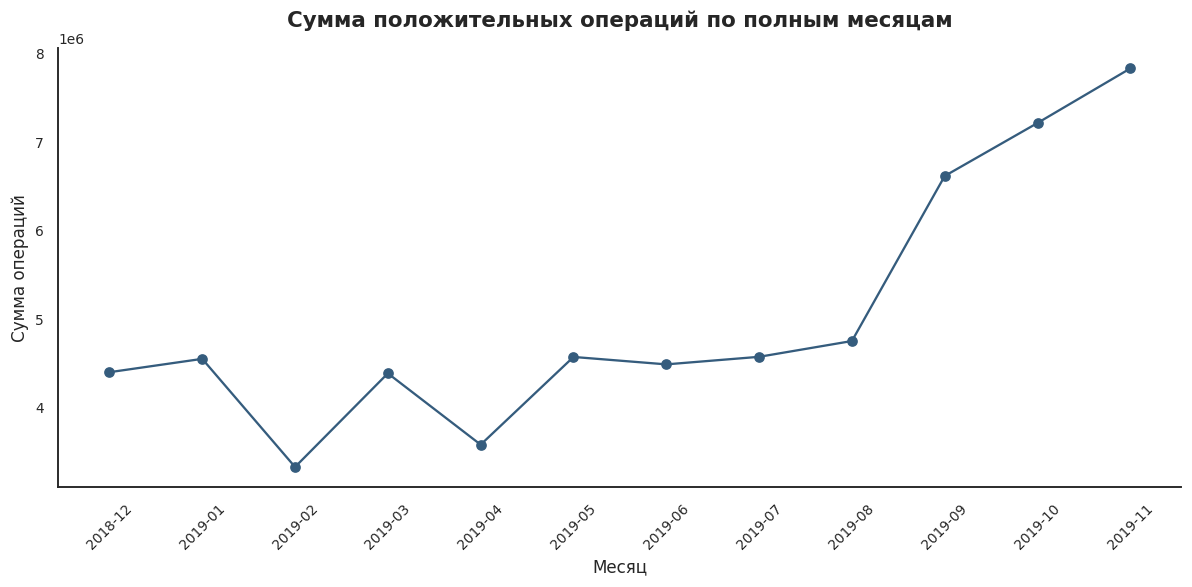

In [58]:
# денежная динамика по полным месяцам
last_period = sales_df["YearMonth"].max()

monthly_sales = (
    order_agg.loc[order_agg["year_month"] < last_period]
    .groupby("year_month", as_index=False)
    .agg(GrossAmount=("total_amount", "sum"))
    .sort_values("year_month")
)
monthly_sales["Period"] = monthly_sales["year_month"].astype("string")

fig, ax = plt.subplots()
ax.plot(monthly_sales["Period"], monthly_sales["GrossAmount"], color=EDA_BLUE, marker='o')

ax.tick_params(axis="x", rotation=45)
finish_chart(
    ax,
    "Сумма положительных операций по полным месяцам",
    "Месяц",
    "Сумма операций"
)
plt.tight_layout()
plt.show()

 Среди полных месяцев максимум зафиксирован в ноябре 2019 года — **£7,83 млн**, минимум — в феврале 2019 года (**£3,33 млн**). С сентября по ноябрь показатель последовательно увеличивается. Декабрь 2019 года в сравнение не включён.


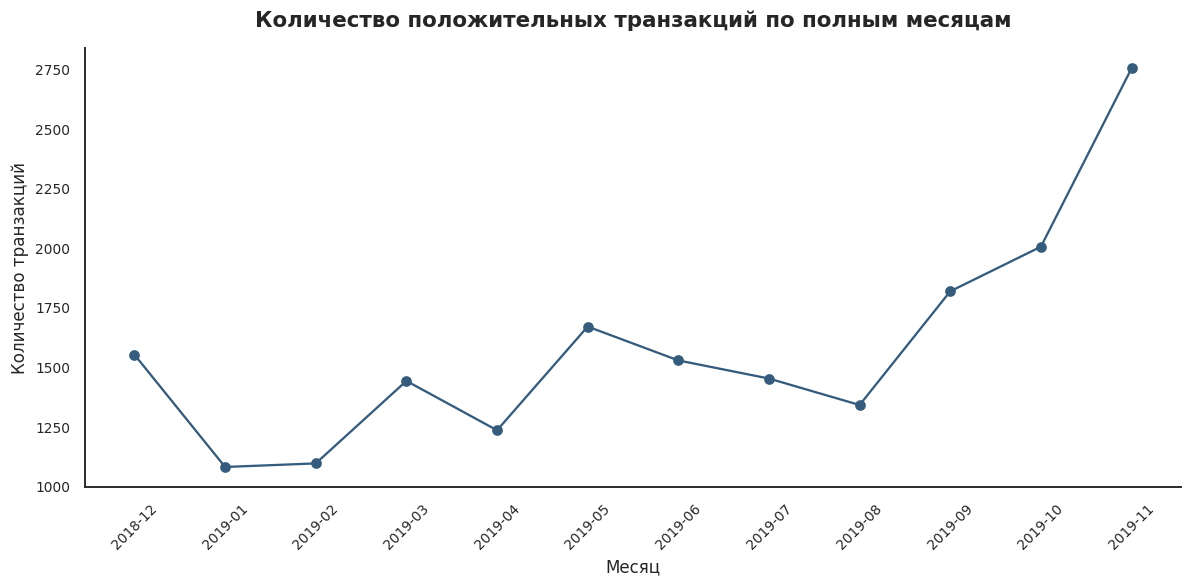

In [59]:
# динамика количества транзакций по полным месяцам

monthly_orders = (
    order_agg.loc[order_agg["year_month"] < last_period]
    .groupby("year_month", as_index=False)
    .agg(OrderCount=("TransactionNo", "nunique"))
    .sort_values("year_month")
)
monthly_orders["Period"] = monthly_orders["year_month"].astype("string")

fig, ax = plt.subplots()
ax.plot(monthly_orders["Period"], monthly_orders["OrderCount"], color=EDA_BLUE, marker='o')
ax.tick_params(axis="x", rotation=45)
finish_chart(
    ax,
    "Количество положительных транзакций по полным месяцам",
    "Месяц",
    "Количество транзакций"
)
plt.tight_layout()
plt.show()

Максимум  приходится на ноябрь 2019 года — **2 753 транзакции**. Минимум — январь 2019 года (**1 081**). Одновременный рост суммы и количества транзакций осенью виден непосредственно в двух помесячных рядах; причина роста этими данными не устанавливается.


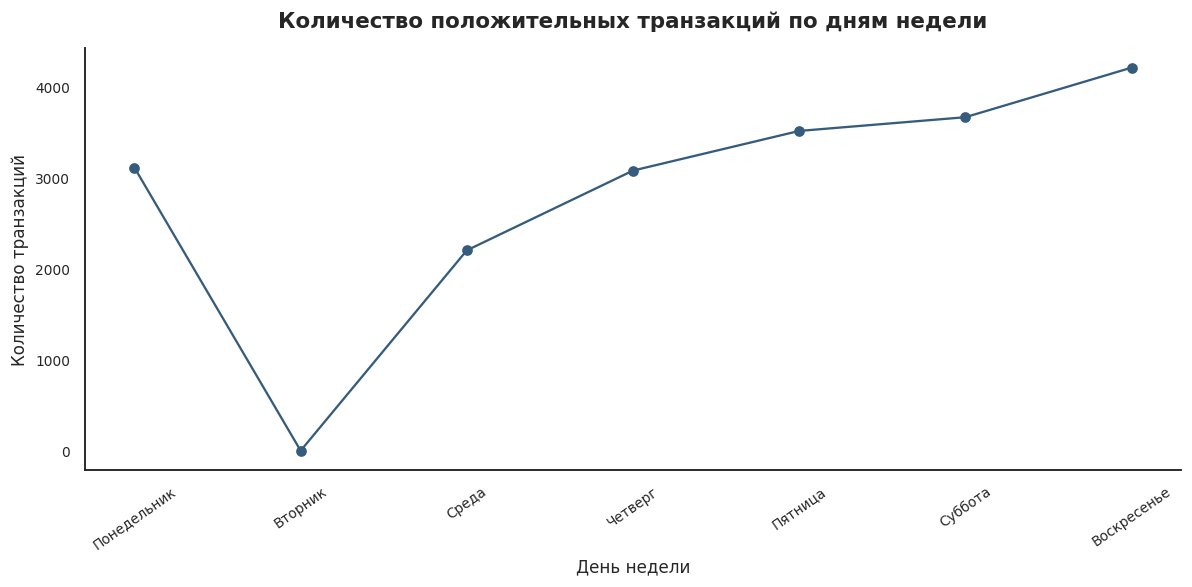

In [60]:
# распределение транзакций по дням недели

weekday_order = pd.DataFrame({
    "day_of_week": range(7),
    "Day": [
        "Понедельник", "Вторник", "Среда", "Четверг",
        "Пятница", "Суббота", "Воскресенье"
    ]
})

weekday_orders = (
    order_agg.groupby("day_of_week", as_index=False)
    .agg(OrderCount=("TransactionNo", "nunique"))
    .merge(weekday_order, on="day_of_week", how="right")
    .fillna({"OrderCount": 0})
    .sort_values("day_of_week")
)

fig, ax = plt.subplots()
ax.plot(weekday_orders["Day"], weekday_orders["OrderCount"], color=EDA_BLUE, marker='o')
ax.tick_params(axis="x", rotation=35)
finish_chart(
    ax,
    "Количество положительных транзакций по дням недели",
    "День недели",
    "Количество транзакций"
)
plt.tight_layout()
plt.show()

Больше всего положительных транзакций приходится на воскресенье (**4 212**), меньше всего среди представленных дней — на среду (**2 203**). По вторникам в данных нет транзакций. Причину отсутствия вторников по этому датасету подтвердить нельзя.


## **Шаг 3.2. Сумма транзакции и состав корзины**


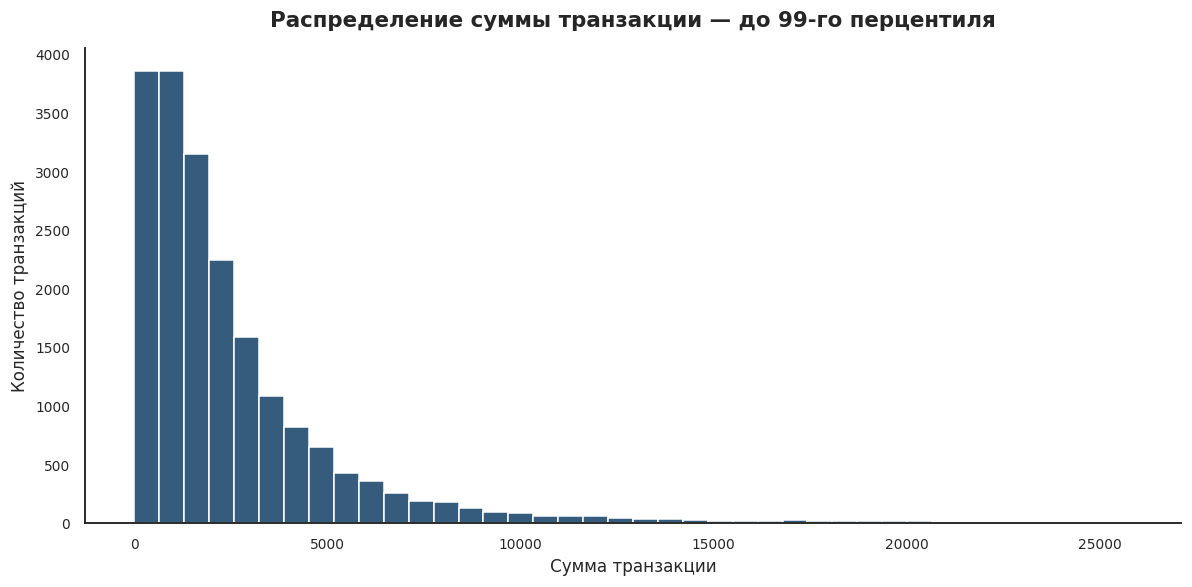

In [61]:
# Распределение суммы положительной транзакции

order_amount_limit = order_agg["total_amount"].quantile(0.99)
order_amount_for_plot = (
    order_agg.loc[
        order_agg["total_amount"] <= order_amount_limit,
        "total_amount"
    ].sort_values()
)

fig, ax = plt.subplots()
ax.hist(order_amount_for_plot, bins=40, color=EDA_BLUE, edgecolor="white")
finish_chart(
    ax,
    "Распределение суммы транзакции — до 99-го перцентиля",
    "Сумма транзакции",
    "Количество транзакций"
)
plt.tight_layout()
plt.show()


 Распределение имеет длинный правый хвост. Медиана равна **£1 709,42**, а 99-й перцентиль — **£25 822,64**. Для читаемости на графике показаны первые 99% транзакций; оставшийся 1% не удалён из данных и общих расчётов.


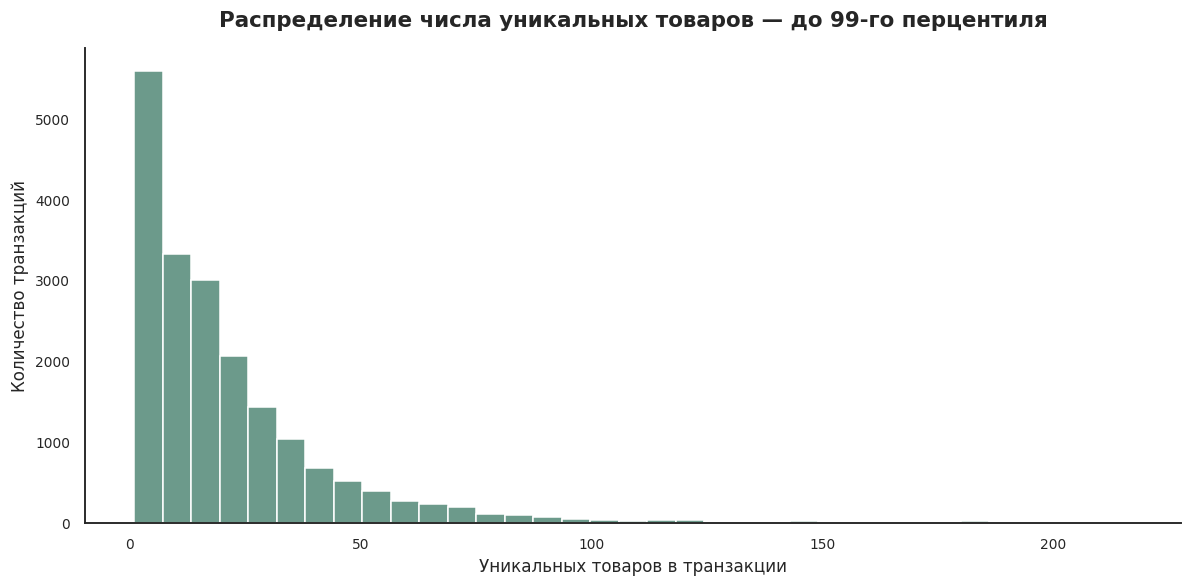

In [62]:
#Распределение числа уникальных товаров в транзакции

product_count_limit = order_agg["unique_products"].quantile(0.99)
product_count_for_plot = (
    order_agg.loc[
        order_agg["unique_products"] <= product_count_limit,
        "unique_products"
    ].sort_values()
)

fig, ax = plt.subplots()
ax.hist(product_count_for_plot, bins=35, color=EDA_GREEN, edgecolor="white")
finish_chart(
    ax,
    "Распределение числа уникальных товаров — до 99-го перцентиля",
    "Уникальных товаров в транзакции",
    "Количество транзакций"
)
plt.tight_layout()
plt.show()


Медианная транзакция содержит **15 уникальных товаров**, 75-й перцентиль — **29**, 99-й — примерно **217**. Как и сумма транзакции, состав корзины распределён несимметрично.


## **Шаг 3.3. Товары**


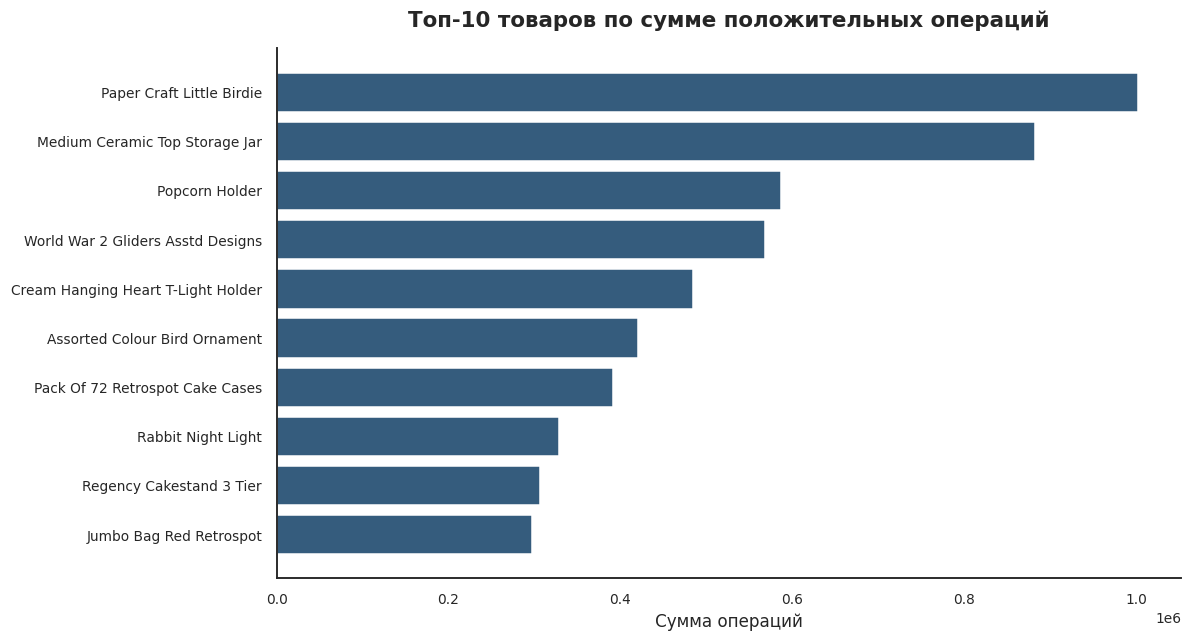

In [63]:
# единая товарная агрегация положительных операций

product_stats = (
    sales_df.groupby(["ProductNo", "ProductName"], as_index=False)
    .agg(
        GrossAmount=("TotalAmount", "sum"),
        Quantity=("Quantity", "sum"),
        OrderCount=("TransactionNo", "nunique")
    )
)

top_products_amount = (
    product_stats.nlargest(10, "GrossAmount")
    .sort_values("GrossAmount")
)

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(top_products_amount["ProductName"], top_products_amount["GrossAmount"], color=EDA_BLUE)

finish_chart(
    ax,
    "Топ-10 товаров по сумме положительных операций",
    "Сумма операций",
    ""
)
plt.tight_layout()
plt.show()


 лидер — **Paper Craft Little Birdie** с **£1,00 млн**, но эта сумма сформирована одной положительной транзакцией; на Этапе 1 для неё найден обратный возврат по количеству. Поэтому рейтинг показывает валовую сумму положительных операций, а не устойчивость товарного спроса.


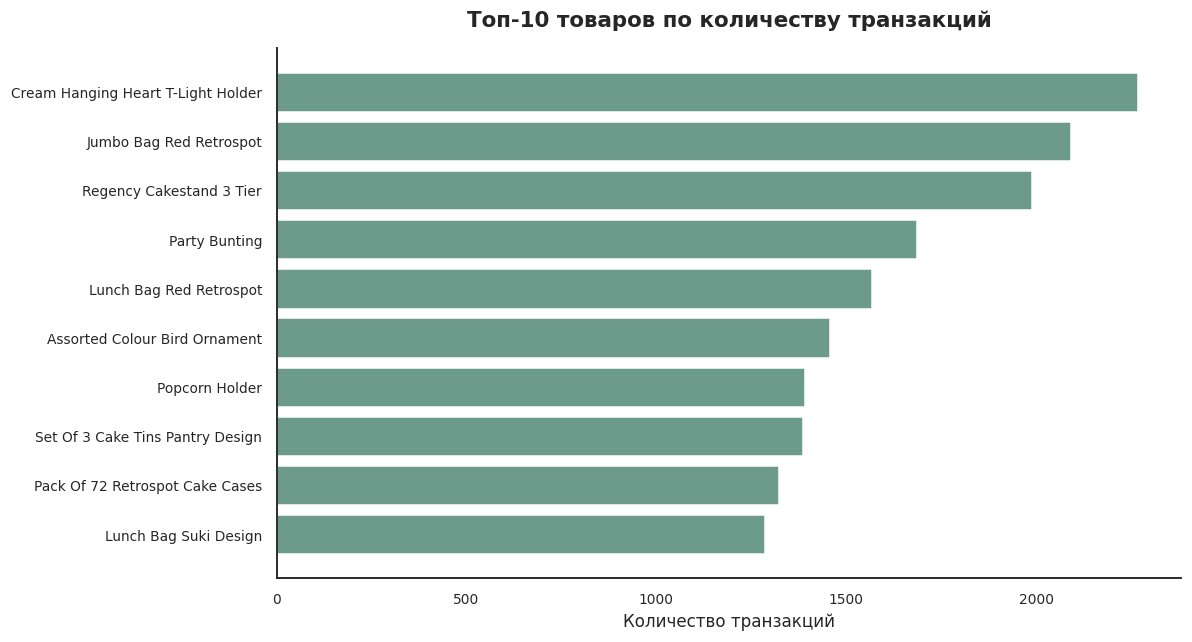

In [64]:
# товары по частоте присутствия в транзакциях

top_products_orders = (
    product_stats.nlargest(10, "OrderCount")
    .sort_values("OrderCount")
)

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(top_products_orders["ProductName"], top_products_orders["OrderCount"], color=EDA_GREEN)
finish_chart(
    ax,
    "Топ-10 товаров по количеству транзакций",
    "Количество транзакций",
    ""
)
plt.tight_layout()
plt.show()


 наиболее регулярно встречается **Cream Hanging Heart T-Light Holder** — в **2 269 транзакциях**, или **11,47%** всех положительных транзакций. Рейтинг по частоте отличается от рейтинга по денежной сумме.


## **Шаг 3.4. Клиенты**

Технический клиент `-1` исключается из клиентских распределений.


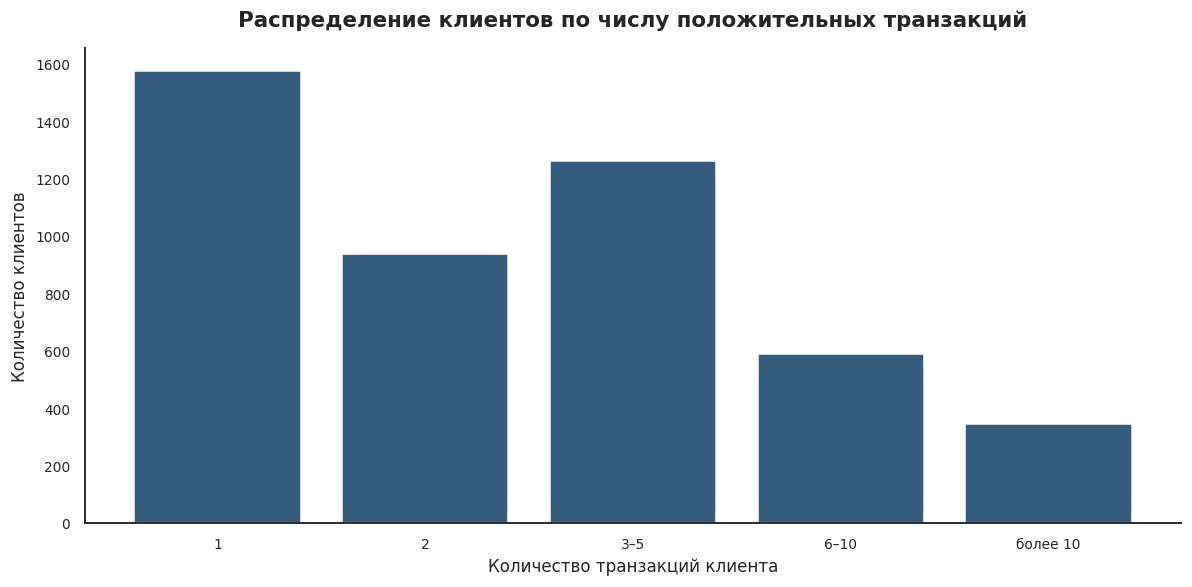

In [65]:
#  частота положительных транзакций клиентов

customer_stats = (
    order_agg.loc[order_agg["customer_no"] != -1]
    .groupby("customer_no", as_index=False)
    .agg(
        OrderCount=("TransactionNo", "nunique"),
        GrossAmount=("total_amount", "sum"),
        AverageOrder=("total_amount", "mean"),
        FirstDate=("date", "min"),
        LastDate=("date", "max")
    )
)

frequency_labels = ["1", "2", "3–5", "6–10", "более 10"]
customer_stats["FrequencyGroup"] = pd.cut(
    customer_stats["OrderCount"],
    bins=[0, 1, 2, 5, 10, float("inf")],
    labels=frequency_labels
)

customer_frequency = (
    customer_stats["FrequencyGroup"]
    .value_counts()
    .reindex(frequency_labels)
)

fig, ax = plt.subplots()
ax.bar(customer_frequency.index.astype("string"), customer_frequency.values, color=EDA_BLUE)
finish_chart(
    ax,
    "Распределение клиентов по числу положительных транзакций",
    "Количество транзакций клиента",
    "Количество клиентов"
)
plt.tight_layout()
plt.show()


**1 577 клиентов (33,43%)** имеют одну положительную транзакцию, **3 141 (66,57%)** — больше одной. Это описывает повторяемость операций внутри периода, но не измеряет удержание без когортного анализа.


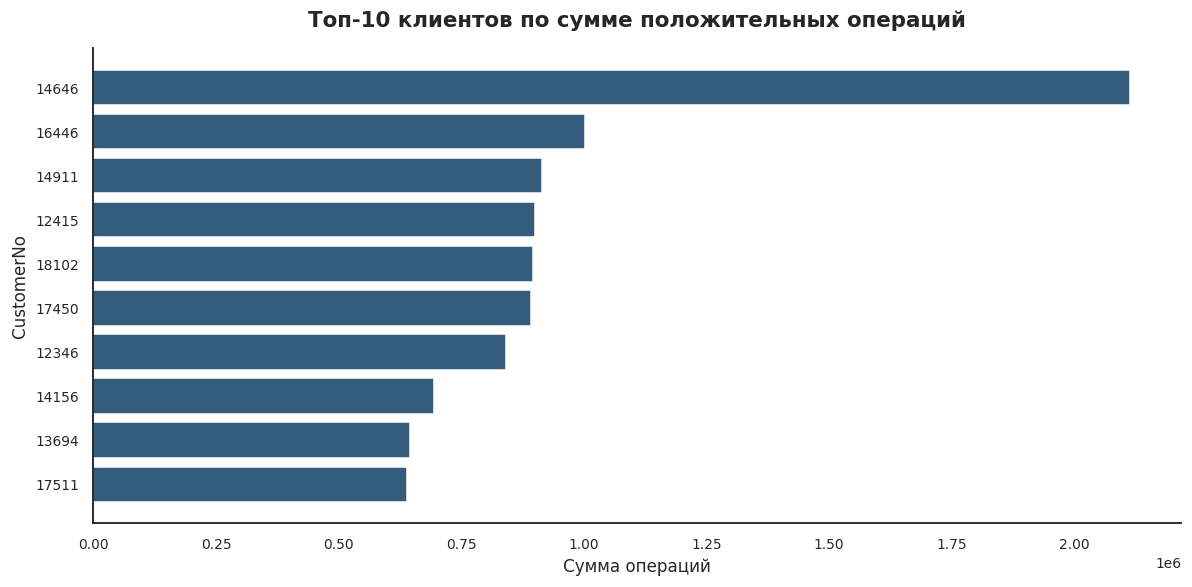

In [66]:
#  клиенты по сумме положительных операций
top_customers = (
    customer_stats.nlargest(10, "GrossAmount")
    .sort_values("GrossAmount")
)

fig, ax = plt.subplots()
ax.barh(top_customers["customer_no"].astype("string"), top_customers["GrossAmount"], color=EDA_BLUE)
finish_chart(
    ax,
    "Топ-10 клиентов по сумме положительных операций",
    "Сумма операций",
    "CustomerNo"
)
plt.tight_layout()
plt.show()


 клиент **14646** лидирует с **£2,11 млн** положительных операций и 73 транзакциями. Верхние 10% клиентов по сумме формируют **59,02%** положительного денежного объёма. Это показатель концентрации, а не прибыли или пожизненной ценности клиента.


## **Шаг 3.5. География**


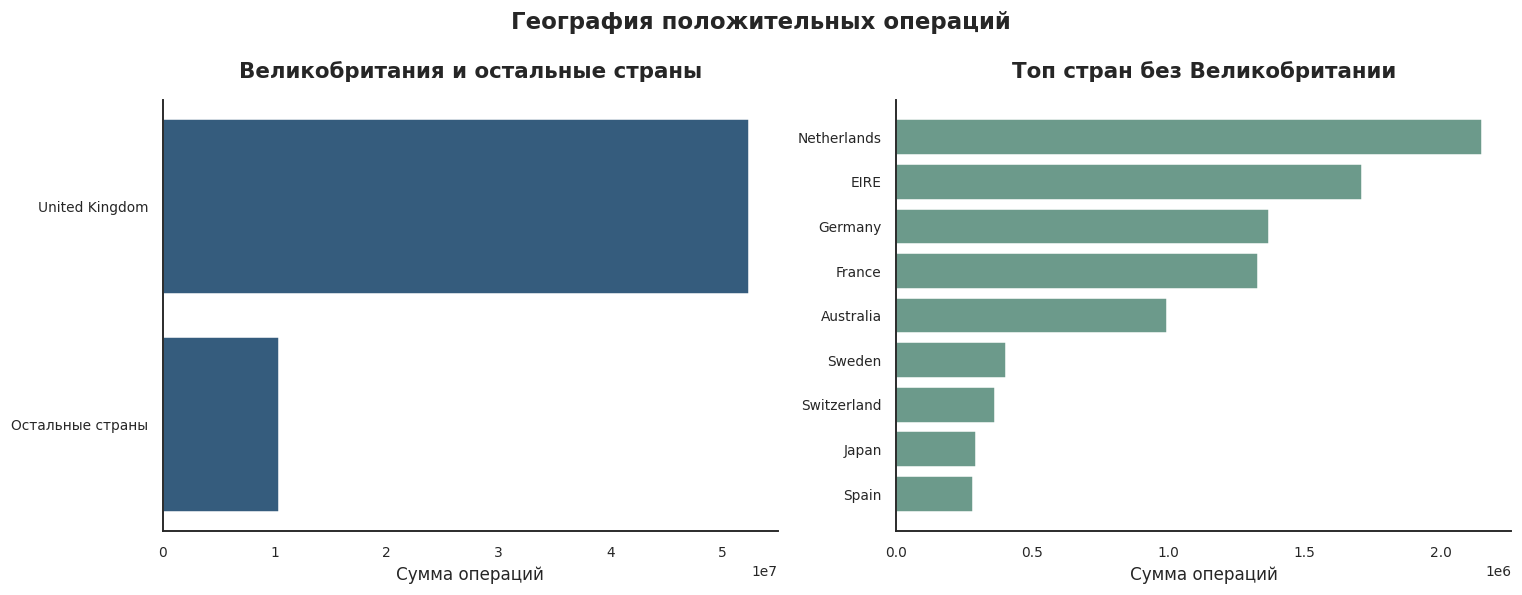

In [67]:
# страны по сумме положительных операций

country_stats = (
    order_agg.groupby("country", as_index=False)
    .agg(
        GrossAmount=("total_amount", "sum"),
        OrderCount=("TransactionNo", "nunique"),
        AverageOrder=("total_amount", "mean")
    )
)

top_countries_amount = (
    country_stats.nlargest(10, "GrossAmount")
    .sort_values("GrossAmount")
)

uk_vs_other = pd.DataFrame({
    "Market": ["Остальные страны", "United Kingdom"],
    "GrossAmount": [
        country_stats.loc[
            country_stats["country"] != "United Kingdom",
            "GrossAmount"
        ].sum(),
        country_stats.loc[
            country_stats["country"] == "United Kingdom",
            "GrossAmount"
        ].sum()
    ]
}).sort_values("GrossAmount")

top_countries_without_uk = (
    country_stats.loc[country_stats["country"] != "United Kingdom"]
    .nlargest(9, "GrossAmount")
    .sort_values("GrossAmount")
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
axes[0].barh(uk_vs_other["Market"], uk_vs_other["GrossAmount"], color=EDA_BLUE)

finish_chart(
    axes[0],
    "Великобритания и остальные страны",
    "Сумма операций",
    ""
)

axes[1].barh(
    top_countries_without_uk["country"],
    top_countries_without_uk["GrossAmount"],
    color=EDA_GREEN
)

finish_chart(
    axes[1],
    "Топ стран без Великобритании",
    "Сумма операций",
    ""
)

fig.suptitle(
    "География положительных операций",
    fontsize=15,
    fontweight="bold"
)
plt.tight_layout()
plt.show()


Великобритания формирует **£52,35 млн**, или **83,38%** суммы положительных операций, и **90,49%** транзакций. Географическое распределение сильно сконцентрировано на одном рынке.


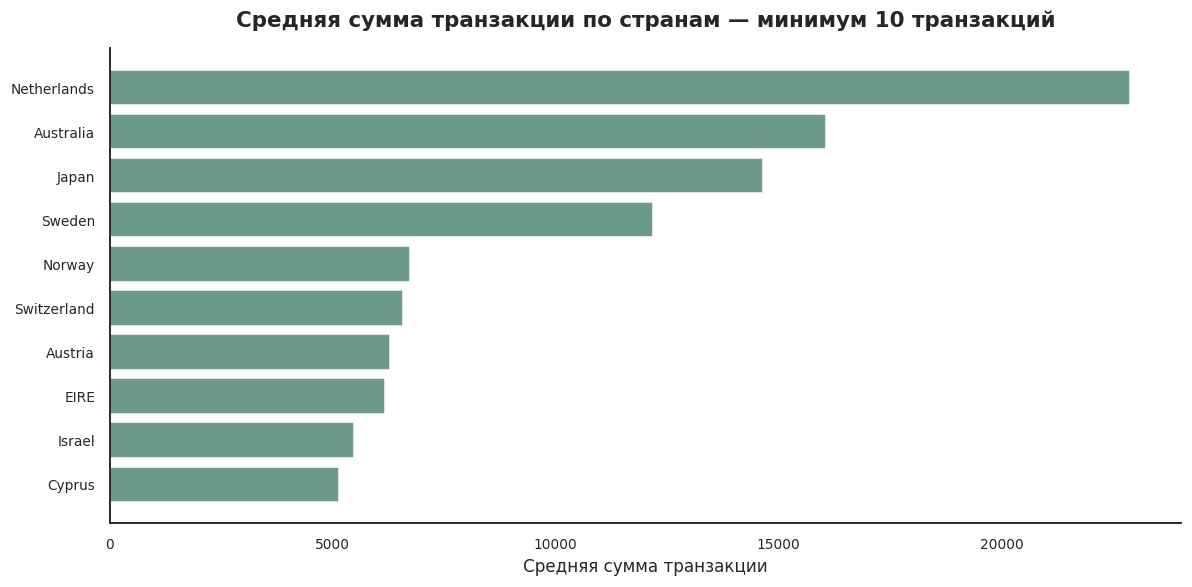

In [68]:
# средняя сумма транзакции по странам с достаточным числом наблюдений

country_average_filtered = (
    country_stats.loc[country_stats["OrderCount"] >= 10]
    .nlargest(10, "AverageOrder")
    .sort_values("AverageOrder")
)

fig, ax = plt.subplots()
ax.barh(country_average_filtered["country"], country_average_filtered["AverageOrder"], color=EDA_GREEN)

finish_chart(
    ax,
    "Средняя сумма транзакции по странам — минимум 10 транзакций",
    "Средняя сумма транзакции",
    ""
)
plt.tight_layout()
plt.show()


 среди стран минимум с 10 транзакциями максимальная средняя сумма зафиксирована в Нидерландах — **£22 888,87**, затем в Австралии (**£16 055,06**) и Японии (**£14 657,77**). Порог в 10 транзакций установлен, чтобы не ранжировать страны по единичным операциям.


## **Шаг 3.6. Возвратные операции**

Возвраты показаны отдельно и не смешиваются с положительными транзакциями.


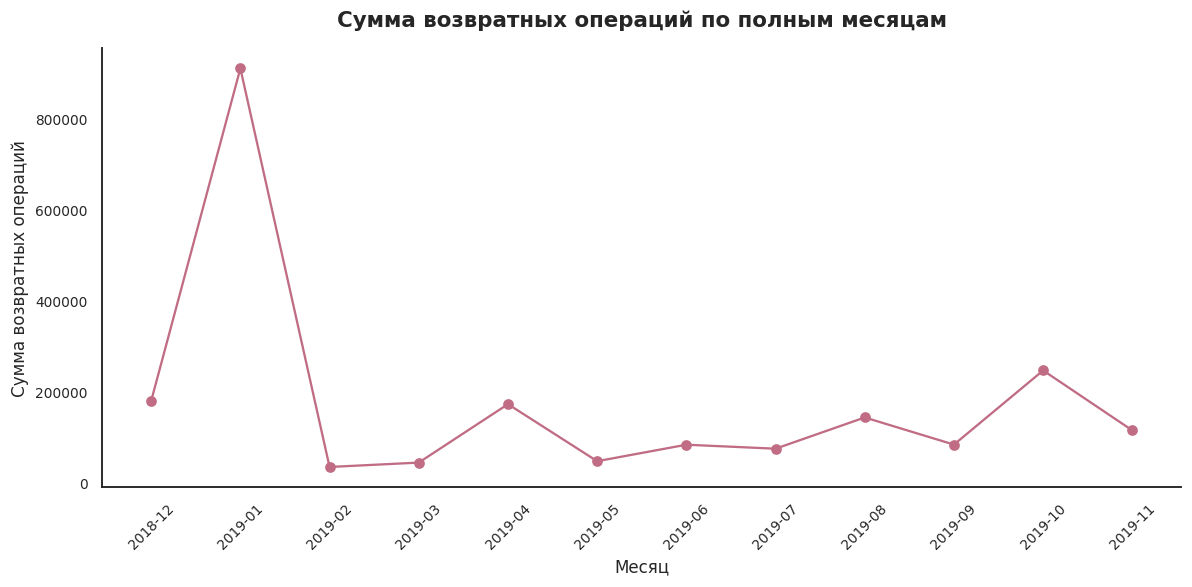

In [69]:
# сумма возвратных операций по полным месяцам

monthly_returns = (
    return_agg.loc[return_agg["year_month"] < last_period]
    .groupby("year_month", as_index=False)
    .agg(ReturnAmount=("total_return_amount", "sum"))
    .sort_values("year_month")
)
monthly_returns["Period"] = monthly_returns["year_month"].astype("string")

fig, ax = plt.subplots()
ax.plot(monthly_returns["Period"], monthly_returns["ReturnAmount"], color=EDA_ACCENT, marker='o')

ax.tick_params(axis="x", rotation=45)
finish_chart(
    ax,
    "Сумма возвратных операций по полным месяцам",
    "Месяц",
    "Сумма возвратных операций"
)
plt.tight_layout()
plt.show()

январь 2019 года резко выделяется — **£910,34 тыс.** возвратных операций, или **34,16%** их суммы за весь период. Поэтому средний уровень возвратов по месяцам без учёта структуры отдельных крупных операций был бы вводящим в заблуждение.


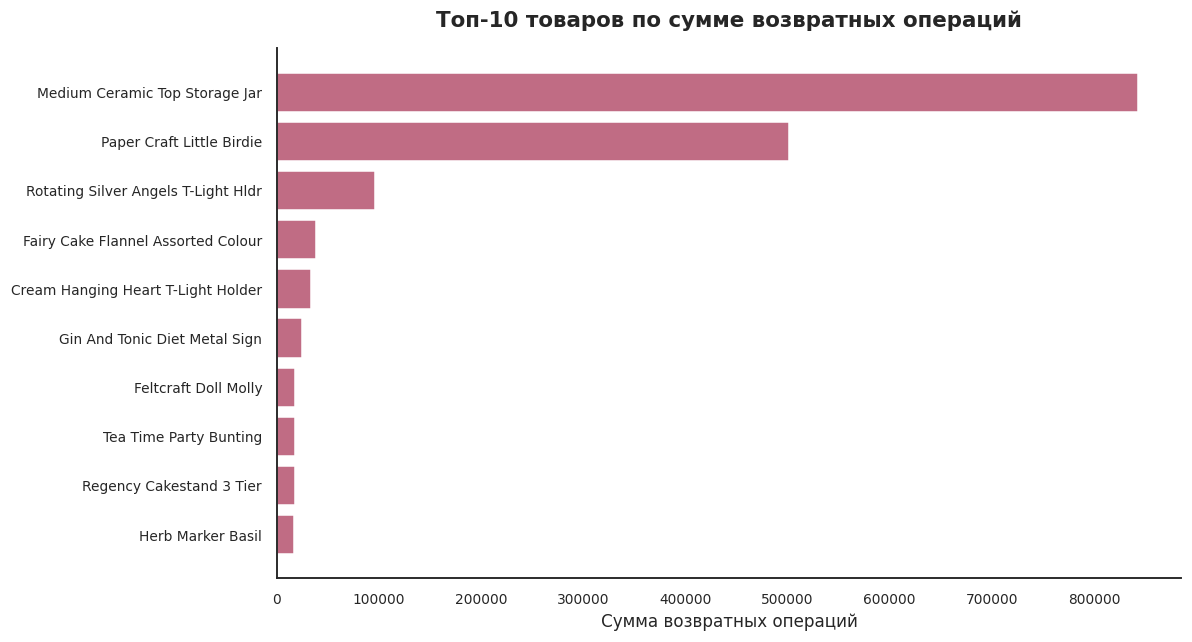

In [70]:
# товары по сумме возвратных операций

return_product_stats = (
    returns_df.groupby(["ProductNo", "ProductName"], as_index=False)
    .agg(
        ReturnAmount=("ReturnAmount", "sum"),
        ReturnQuantity=("Quantity", lambda values: values.abs().sum()),
        ReturnTransactions=("TransactionNo", "nunique")
    )
)

top_return_products = (
    return_product_stats.nlargest(10, "ReturnAmount")
    .sort_values("ReturnAmount")
)

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(top_return_products["ProductName"], top_return_products["ReturnAmount"], color=EDA_ACCENT)

finish_chart(
    ax,
    "Топ-10 товаров по сумме возвратных операций",
    "Сумма возвратных операций",
    ""
)
plt.tight_layout()
plt.show()


 **Medium Ceramic Top Storage Jar** формирует **£843,28 тыс.**, или **31,65%** суммы возвратных операций; **Paper Craft Little Birdie** — ещё **18,82%**. Возвратный денежный объём концентрируется в нескольких крупных товарных операциях.


## **Шаг 3.7. Цены и ценовые интервалы**


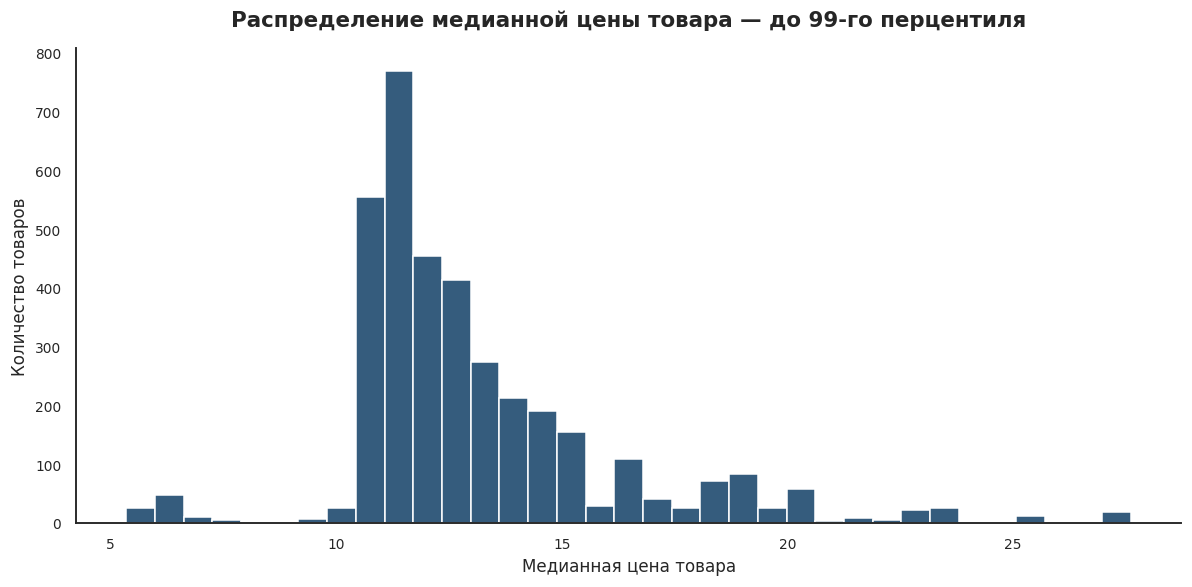

In [71]:
#  распределение типичной цены товара

representative_product_price = (
    sales_df.groupby(["ProductNo", "ProductName"])["Price"]
    .median()
    .sort_values()
)
price_limit = representative_product_price.quantile(0.99)
price_for_plot = representative_product_price.loc[
    representative_product_price <= price_limit
]

fig, ax = plt.subplots()
ax.hist(price_for_plot, bins=35, color=EDA_BLUE, edgecolor="white")

finish_chart(
    ax,
    "Распределение медианной цены товара — до 99-го перцентиля",
    "Медианная цена товара",
    "Количество товаров"
)
plt.tight_layout()
plt.show()


> среди **3 753 товаров**, представленных в положительных операциях, медианная цена равна **£12,25**, а 99-й перцентиль — **£27,62**. График ограничен 99-м перцентилем только для масштаба; дорогие позиции остаются в данных.


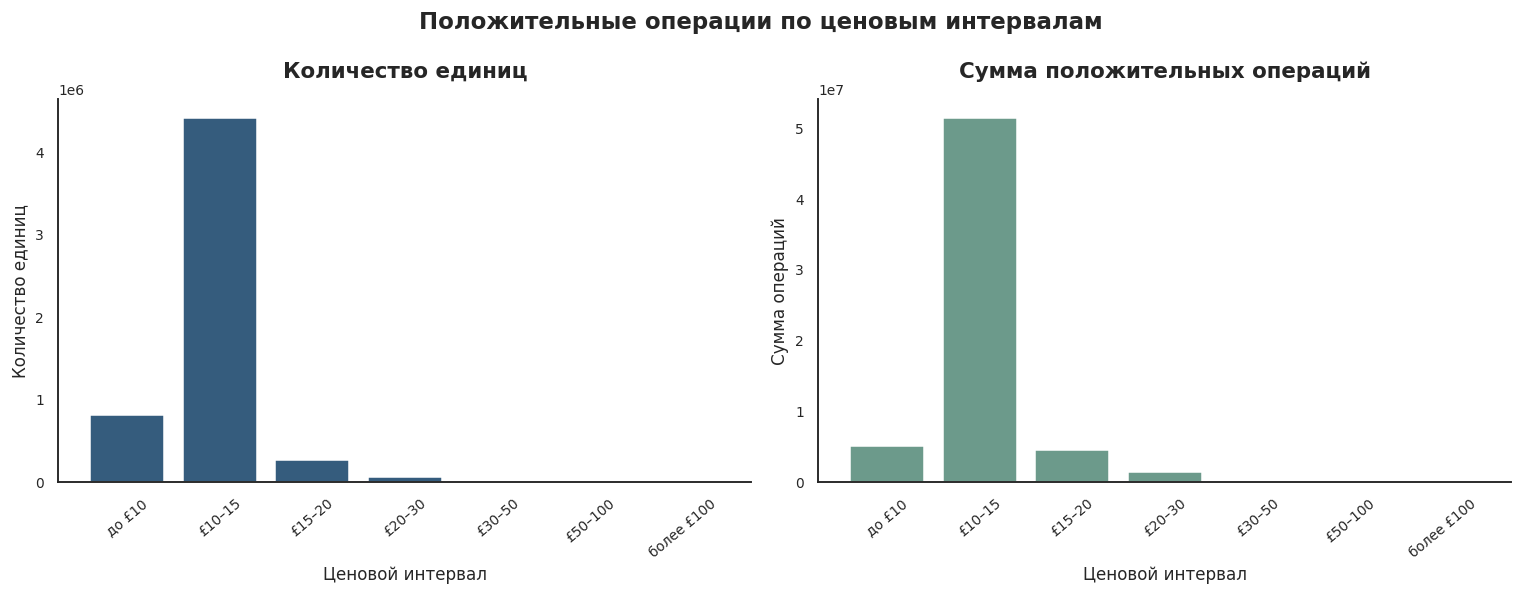

In [72]:
# количество единиц и денежная сумма по ценовым интервалам

price_labels = [
    "до £10", "£10–15", "£15–20", "£20–30",
    "£30–50", "£50–100", "более £100"
]

sales_with_segment = sales_df.assign(
    PriceSegment=pd.cut(
        sales_df["Price"],
        bins=[0, 10, 15, 20, 30, 50, 100, float("inf")],
        labels=price_labels,
        right=False
    )
)

price_segment_stats = (
    sales_with_segment.groupby("PriceSegment", observed=False, as_index=False)
    .agg(
        Quantity=("Quantity", "sum"),
        GrossAmount=("TotalAmount", "sum")
    )
    .set_index("PriceSegment")
    .reindex(price_labels)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
axes[0].bar(price_segment_stats["PriceSegment"].astype("string"), price_segment_stats["Quantity"], color=EDA_BLUE)

axes[0].tick_params(axis="x", rotation=40)
finish_chart(axes[0], "Количество единиц", "Ценовой интервал", "Количество единиц")

axes[1].bar(price_segment_stats["PriceSegment"].astype("string"), price_segment_stats["GrossAmount"], color=EDA_GREEN)

axes[1].tick_params(axis="x", rotation=40)
finish_chart(axes[1], "Сумма положительных операций", "Ценовой интервал", "Сумма операций")

fig.suptitle("Положительные операции по ценовым интервалам", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()


 интервал **£10–15** формирует **79,30%** проданных единиц и **82,07%** суммы положительных операций. Это описательная концентрация по выбранным интервалам; она не доказывает причинную зависимость спроса от цены и не позволяет рекомендовать изменение цен.


---
---

## **Выводы этапа 3**

На третьем этапе был проведен глубокий исследовательский анализ данных, выявивший ряд ключевых закономерностей и инсайтов:

1.  **Динамика продаж:**
    *   Наблюдается выраженная сезонность с пиком выручки и количества заказов в осенние месяцы (сентябрь, октябрь, ноябрь), особенно в **ноябре**, который является самым доходным месяцем (**7.71 млн руб.** и **3,146** заказов).
    *   Значительный спад продаж приходится на начало года (январь, февраль, апрель).
    *   Наибольшая выручка генерируется в выходные дни (**суббота, воскресенье**) и в конце рабочей недели (**пятница**), тогда как среда является наименее доходным днём.

2.  **Анализ товаров:**
    *   **Popcorn Holder** и **World War 2 Gliders Asstd Designs** являются лидерами как по выручке, так и по количеству продаж, указывая на их высокую популярность и значительный вклад в общие доходы.
    *   Распределение цен имеет длинный правый хвост: большинство товаров находятся в низком ценовом сегменте, но существует небольшое количество значительно более дорогих позиций, которые могут приносить существенную выручку.

3.  **Анализ клиентов:**
    *   Большая часть клиентов (**70.1%**) являются повторными, что указывает на хорошую лояльность, однако значительная доля (**29.9%**) – это новые клиенты, совершившие только одну покупку. Это подчеркивает потенциал для увеличения удержания.
    *   Среднее количество заказов на клиента составляет **4.90**, но медианное значение — **3**, что говорит о наличии очень активных клиентов, которые совершают множество покупок.

4.  **Географический анализ:**
    *   Подавляющая часть выручки (**82.9%**) и заказов (**90.3%**) приходится на **Великобританию**. Это создает сильную зависимость от одного рынка.
    *   Некоторые страны, такие как **Нидерланды, Сингапур и Австралия**, демонстрируют значительно более высокий средний чек по сравнению с Великобританией, что может указывать на возможности для развития на этих рынках.

5.  **Анализ ценовых сегментов:**
    *   Наблюдается **слабая отрицательная корреляция (-0.206)** между ценой и количеством продаж, что означает, что более дорогие товары, как правило, продаются в меньших количествах.
    *   Основной объем продаж и выручки приходится на ценовой сегмент **«10–20 руб.»**, что подтверждает популярность товаров средней ценовой категории.

**Общий вывод:**
Магазин имеет сильную зависимость от британского рынка и выраженную сезонность продаж. Присутствуют как высоколиквидные товары, так и потенциал для увеличения удержания клиентов. Анализ выявил перспективные рынки с высоким средним чеком, которые могут быть точками роста.

---
---
---

# **Этап 4. Ключевые выводы и рекомендации**
*   Формирование основных инсайтов по каждому блоку анализа.
*   Разработка практических рекомендаций для увеличения выручки, удержания клиентов и оптимизации ассортимента.

## **Итого:**

Исследование показало, что бизнес‑модель магазина является **двухскоростной**: высокая общая выручка (£60,1 млн нетто за 12 месяцев) держится на трёх китах – **британский рынок** (83,4% выручки), **топ‑10% клиентов** (дают 59% оборота) и **ценовой сегмент £10–15** (82% продаж). Такая структура создаёт иллюзию стабильности, но несёт системные риски:

- **Географическая монозависимость** – любой локальный кризис в Великобритании ударит по всему бизнесу.
- **Низкое удержание** – 33,4% клиентов совершают только одну покупку, потенциал повторных продаж используется не полностью.
- **Скрытые потери от возвратов** – £2,66 млн (4,2% от валовой выручки), при этом 50% суммы возвратов приходится на два товара («Medium Ceramic Top Storage Jar» – 31,6%, «Paper Craft Little Birdie» – 18,8%).
- **Неиспользованная возможность** – международные рынки (Нидерланды, Австралия, Япония) показывают средний чек в **5–7 раз выше**, чем в UK, но их доля в обороте ничтожна.



## **Рекомендации**

Для устойчивого роста необходимо  диверсифицировать географию, повысить удержание «одноразовых» клиентов и снизить возвратные потери, одновременно усиливая кросс‑продажи в уже работающих ценовых нишах.

----
  Действия которые помогут увеличить выручку, снизить потери и сделать бизнес более устойчивым:

- **Начать  активно продавать за границу**. В Нидерландах, Австралии и Японии средний чек в 5–7 раз выше, чем в Великобритании. Запустите пробные рекламные кампании и упростите доставку в эти страны – это снизит зависимость от одного рынка.

- **Возврат клиентов**. Каждый третий покупатель (33%) не возвращается. Предложите им скидку 10–15% на второй заказ в течение месяца – это недорогой способ увеличить продажи без привлечения новых клиентов.

- **Возрат товаров**. Две позиции – «Medium Ceramic Top Storage Jar» и «Paper Craft Little Birdie» – дают половину всех возвратов. Проверьте их качество, описание и упаковку. Исправление этих проблем может сэкономить более полумиллиона фунтов.

- **Внимание крупным клиентам**. Всего 10% покупателей приносят 60% выручки. Введите для них персональные предложения и ранний доступ к новинкам – это снизит риск их ухода к конкурентам.

 - **Спад в январе и феврале.** В эти месяцы продажи падают в 2,5 раза по сравнению с ноябрём. Запускайте сезонные акции и используйте историю покупок для персонализированных предложений.

 ---

Продовать сопутствующие товары в ценовом диапазоне **£10–15**. Здесь сосредоточена основная выручка (82%). Размещайте на страницах популярных товаров рекомендации дополнительных позиций из этого же ценового сегмента.

----
----
----